In [1]:
# ===== CELL 1 =====
# ============================================================
# Estimator notebook — ELE8101 CW2
# B1 Single-run EKF | B2 Monte Carlo | B3 MHE comparison
# B4 9-state augmented EKF (bias) | B5 Beacon ablation | B6 Near-boundary
# ============================================================
# Conventions follow the lecturer's 5_ekf.ipynb (Cell 31-33 nonlinear
# branch) and 2_bayesian_fie.ipynb. CasADi automatic differentiation
# provides every Jacobian (h, jhx, jhv, jfx, jfw); no hand-coded matrices
# survive in the prediction step.
# ============================================================

!pip install casadi -q

import numpy as np
import matplotlib.pyplot as plt
import casadi.casadi as cs
import scipy.optimize as sopt
import time, timeit, json, os

# ── Master seed for all stochastic experiments ───────────────────────────
MASTER_SEED = 42
SEED_B1 = MASTER_SEED + 1   # B1 single run
SEED_B2 = MASTER_SEED + 2   # B2 Monte Carlo (trial uses SEED_B2 + trial)
SEED_B3 = MASTER_SEED + 3   # B3 MHE
SEED_B4 = MASTER_SEED + 4   # B4 augmented EKF
SEED_B5 = MASTER_SEED + 5   # B5 ablation (trial uses SEED_B5 + trial)
SEED_B6 = MASTER_SEED + 6   # B6 near-boundary

os.makedirs('Figures_WeitingWu', exist_ok=True)

# ── Track geometry (A1, modelling notebook) ──────────────────────────────
R_outer = 50.0; r_inner = 46.0; rho = 20.0; d = 100.0
R_A   = (R_outer + r_inner) / 2
w     = (R_outer - r_inner) / 2
R_B   = rho + w
alpha = np.arcsin((R_A - R_B) / d)
cos_a = np.cos(alpha);  sin_a = np.sin(alpha)
l_tan = np.sqrt(d**2 - (R_A - R_B)**2)
L     = 2*l_tan + R_A*(np.pi + 2*alpha) + R_B*(np.pi - 2*alpha)
s1    = l_tan
s2    = s1 + R_B*(np.pi - 2*alpha)
s3    = s2 + l_tan

A_centre = np.array([0.0, 0.0]);  B_centre = np.array([d, 0.0])
A_top    = A_centre + R_A * np.array([sin_a,  cos_a])
B_bot    = B_centre + R_B * np.array([sin_a, -cos_a])

def s_to_xy(s):
    s = s % L
    if s < s1:
        return A_top + s * np.array([cos_a, -sin_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return B_centre + R_B * np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return B_bot + (s - s2) * np.array([-cos_a, -sin_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return A_centre + R_A * np.array([np.cos(theta), np.sin(theta)])

def s_to_normal(s):
    s = s % L
    if s < s1:
        return np.array([sin_a,  cos_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return np.array([sin_a, -cos_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return np.array([np.cos(theta), np.sin(theta)])

def sl_to_xy(s, ell):
    return s_to_xy(s) + ell * s_to_normal(s)

# ── Problem data (A2/A3/A4) ──────────────────────────────────────────────
dt     = 0.01           # 100 Hz sampling (problem statement)
phi_vs = 0.999          # longitudinal AR(1) damping
phi_1  = 0.9            # lateral velocity damping
k2     = 10.0           # lateral restoring gain at the centreline

anchors = np.array([
    [ -21.1,  73.3],
    [ 121.1,  46.7],
    [  26.3, -60.0],
    [ -52.6,  20.0],
    [  89.5, -46.7],
])
ny = len(anchors)
nx = 4
nw = 2

# Linear nominal Jacobian A_0 — kept only for legacy reference and the
# Lyapunov cross-check in the report. Prediction step uses A_jacobian(x̂).
A_0 = np.array([
    [1,       0,     dt,       0   ],
    [0,       1,     0,        dt  ],
    [0,       0,     phi_vs,   0   ],
    [0, -dt*k2,     0,        phi_1],
])
G    = np.array([[0,0],[0,0],[1,0],[0,1]])
Q    = np.diag([0.5, 0.002])              # confirmed by A4 grid scan
R    = 1.5**2 * np.eye(ny)                # sigma_y = 1.5 m

# ── Bound-respecting nonlinear dynamics (NUMPY) ─────────────────────────
ELL_MAX_NL  = 2.0
VL_MAX_NL   = 0.55
VS_MAX_NL   = 25.0
VS_MIN_NL   = 0.001
VS_TGT_NL   = 10.0
BETA_ELL_NL = 5.0
EPS_NL      = 1e-6

def k_nonlinear(ell):
    safe_denom = np.maximum(ELL_MAX_NL**2 - ell**2, EPS_NL)
    return k2 * (1.0 + BETA_ELL_NL * (ell**2 / safe_denom)**2)

def _squash_np(x, lo, hi):
    mid, half = (hi + lo) / 2, (hi - lo) / 2
    return mid + half * np.tanh((x - mid) / half)

def f_dynamics(z, w_vec):
    """Bound-respecting nonlinear truth dynamics from Section 1.2 of
    the modelling document. Bounds enforced by smooth C-infinity
    construction, no post-hoc clipping."""
    s, ell, vs, vl = z
    w_s, w_ell = w_vec
    s_new   = s + dt * vs
    ell_new = ell + dt * vl
    vs_new  = _squash_np(phi_vs * vs + (1 - phi_vs) * VS_TGT_NL + w_s,
                         VS_MIN_NL, VS_MAX_NL)
    vl_raw  = phi_1 * vl - dt * k_nonlinear(ell) * ell + w_ell
    vl_new  = _squash_np(vl_raw, -VL_MAX_NL, VL_MAX_NL)
    return np.array([s_new, ell_new, vs_new, vl_new])

# ── CasADi-symbolic mirror of f_dynamics for Jacobians ──────────────────
z_d = cs.SX.sym('z_d', nx)
w_d = cs.SX.sym('w_d', nw)

def _squash_cs(x, lo, hi):
    mid, half = (hi + lo) / 2, (hi - lo) / 2
    return mid + half * cs.tanh((x - mid) / half)

_safe_denom_cs = ELL_MAX_NL**2 - z_d[1]**2 + EPS_NL
_k_cs = k2 * (1 + BETA_ELL_NL * (z_d[1]**2 / _safe_denom_cs)**2)

_s_n   = z_d[0] + dt * z_d[2]
_ell_n = z_d[1] + dt * z_d[3]
_vs_n  = _squash_cs(phi_vs * z_d[2] + (1 - phi_vs) * VS_TGT_NL + w_d[0],
                    VS_MIN_NL, VS_MAX_NL)
_vl_n  = _squash_cs(phi_1 * z_d[3] - dt * _k_cs * z_d[1] + w_d[1],
                    -VL_MAX_NL, VL_MAX_NL)

f_sym   = cs.vertcat(_s_n, _ell_n, _vs_n, _vl_n)
f_fun   = cs.Function('f_fun', [z_d, w_d], [f_sym])
jfx_fun = cs.Function('jfx_fun', [z_d, w_d], [cs.jacobian(f_sym, z_d)])
jfw_fun = cs.Function('jfw_fun', [z_d, w_d], [cs.jacobian(f_sym, w_d)])

def A_jacobian(x):
    """A_k = ∂f/∂z evaluated at the current estimate (mirrors lecturer's
    5_ekf.ipynb Cell 33 nonlinear-dynamics example)."""
    return np.array(jfx_fun(x, np.zeros(nw)))

def L_jacobian(x):
    """L_k = ∂f/∂w; lets the prediction-step covariance use the correct
    L_k Q L_k^T form rather than a fixed nominal G Q G^T."""
    return np.array(jfw_fun(x, np.zeros(nw)))

# ── Measurement model h(z, v) — CasADi (unchanged from B1 baseline) ─────
z_ = cs.SX.sym('z_', nx)
v_ = cs.SX.sym('v_', ny)

s_mod  = cs.fmod(z_[0], L)
ell_   = z_[1]

theta2_ = (np.pi/2 - alpha) - (s_mod - s1) / R_B
theta4_ = (-np.pi/2 + alpha) - (s_mod - s3) / R_A

xy1_ = cs.vertcat(A_top[0] + s_mod*cos_a,            A_top[1] - s_mod*sin_a)
xy2_ = cs.vertcat(B_centre[0] + R_B*cs.cos(theta2_), R_B*cs.sin(theta2_))
xy3_ = cs.vertcat(B_bot[0] - (s_mod-s2)*cos_a,       B_bot[1] - (s_mod-s2)*sin_a)
xy4_ = cs.vertcat(R_A*cs.cos(theta4_),                R_A*cs.sin(theta4_))
xy_c = cs.if_else(s_mod < s1, xy1_,
       cs.if_else(s_mod < s2, xy2_,
       cs.if_else(s_mod < s3, xy3_, xy4_)))

n1_ = cs.vertcat(sin_a,  cos_a)
n2_ = cs.vertcat(cs.cos(theta2_), cs.sin(theta2_))
n3_ = cs.vertcat(sin_a, -cos_a)
n4_ = cs.vertcat(cs.cos(theta4_), cs.sin(theta4_))
n_c = cs.if_else(s_mod < s1, n1_,
      cs.if_else(s_mod < s2, n2_,
      cs.if_else(s_mod < s3, n3_, n4_)))

r_  = xy_c + ell_ * n_c
h_  = cs.vertcat(*[cs.norm_2(r_ - anchors[i]) + v_[i] for i in range(ny)])

jhx = cs.Function('jhx', [z_, v_], [cs.jacobian(h_, z_)])
jhv = cs.Function('jhv', [z_, v_], [cs.jacobian(h_, v_)])
h   = cs.Function('h',   [z_, v_], [h_])

# ── EKF primitives (uses A_jacobian and L_jacobian — patches 1 & 10) ─────
def measurement_update(sigma_t_pred, x_t_pred, y_t):
    C            = jhx(x_t_pred, 0)
    Rv           = jhv(x_t_pred, 0)
    Z            = C @ sigma_t_pred @ C.T + Rv @ R @ Rv.T
    x_t_meas     = x_t_pred + sigma_t_pred @ C.T @ np.linalg.solve(
                     Z, y_t - h(x_t_pred, [0]*ny))
    sigma_t_meas = sigma_t_pred - sigma_t_pred @ C.T @ np.linalg.solve(
                     Z, C @ sigma_t_pred)
    return np.array(sigma_t_meas), np.array(x_t_meas).flatten()

def time_update(sigma_t_meas, x_t_meas):
    """Nonlinear prediction step: A_k = ∂f/∂z|_x̂, L_k = ∂f/∂w|_x̂.
    Mirrors 5_ekf.ipynb Cell 33."""
    x_t_pred     = f_dynamics(x_t_meas, np.zeros(nw))
    A_k          = A_jacobian(x_t_meas)
    L_k          = L_jacobian(x_t_meas)
    sigma_t_pred = A_k @ sigma_t_meas @ A_k.T + L_k @ Q @ L_k.T
    sigma_t_pred = 0.5 * (sigma_t_pred + sigma_t_pred.T)   # symmetrise
    return sigma_t_pred, x_t_pred

# ── Circular arc-length error helper ─────────────────────────────────────
def arc_error(s_true, s_est, L_):
    """Wrap (s_est - s_true) into [-L/2, +L/2). Avoids spurious O(L)
    spikes when one trajectory has wrapped around s = L."""
    return np.abs((np.asarray(s_est) - np.asarray(s_true) + L_/2) % L_ - L_/2)

# ── GDOP helper (used by B5 ablation cell) ───────────────────────────────
def compute_gdop(p, sub_anchors):
    diffs = sub_anchors - np.asarray(p)
    dists = np.linalg.norm(diffs, axis=1)
    if np.any(dists < 1e-9):
        return np.inf
    H = diffs / dists[:, None]
    M_ = H.T @ H
    if np.linalg.matrix_rank(M_) < M_.shape[0]:
        return np.inf
    return float(np.sqrt(np.trace(np.linalg.inv(M_))))

# ── Per-step EKF timing benchmark (patch 5) ──────────────────────────────
_x_bench = np.array([0.0, 0.0, 10.0, 0.0])
_y_bench = np.zeros(ny)
_sigma_bench = np.diag([100.0, 1.0, 25.0, 0.5])

_n_reps = 500
_t_meas_ms = timeit.timeit(
    lambda: measurement_update(_sigma_bench, _x_bench, _y_bench),
    number=_n_reps) / _n_reps * 1000.0
_t_time_ms = timeit.timeit(
    lambda: time_update(_sigma_bench, _x_bench),
    number=_n_reps) / _n_reps * 1000.0
_t_step_ms = _t_meas_ms + _t_time_ms

EKF_TIMING = {
    'meas_update_ms':  float(_t_meas_ms),
    'time_update_ms':  float(_t_time_ms),
    'per_step_ms':     float(_t_step_ms),
    'budget_ms':       float(dt * 1000.0),
    'budget_fraction': float(_t_step_ms / (dt * 1000.0)),
    'reps_per_kind':   _n_reps,
}

print("Cell 1 ready (Estimator setup)")
print(f"  Track length L = {L:.4f} m,  state nx={nx},  measurement ny={ny}")
print(f"  Q = diag({Q[0,0]}, {Q[1,1]}),  sigma_y = {np.sqrt(R[0,0]):.2f} m")
print(f"  Master seed = {MASTER_SEED}")
print(f"  Per-step EKF runtime  = {_t_step_ms:.3f} ms"
      f"  (budget 10 ms, using {EKF_TIMING['budget_fraction']*100:.1f}%)")

Cell 1 ready (Estimator setup)
  Track length L = 426.7104 m,  state nx=4,  measurement ny=5
  Q = diag(0.5, 0.002),  sigma_y = 1.50 m
  Master seed = 42
  Per-step EKF runtime  = 0.429 ms  (budget 10 ms, using 4.3%)


B1 results (seed=43):
  mean arc-length error : 0.239 m
  mean lateral error    : 0.022 m
  mean velocity error   : 1.793 m/s
  max  velocity error   : 8.160 m/s
  lateral bounds OK     : True
  speed bounds OK       : True


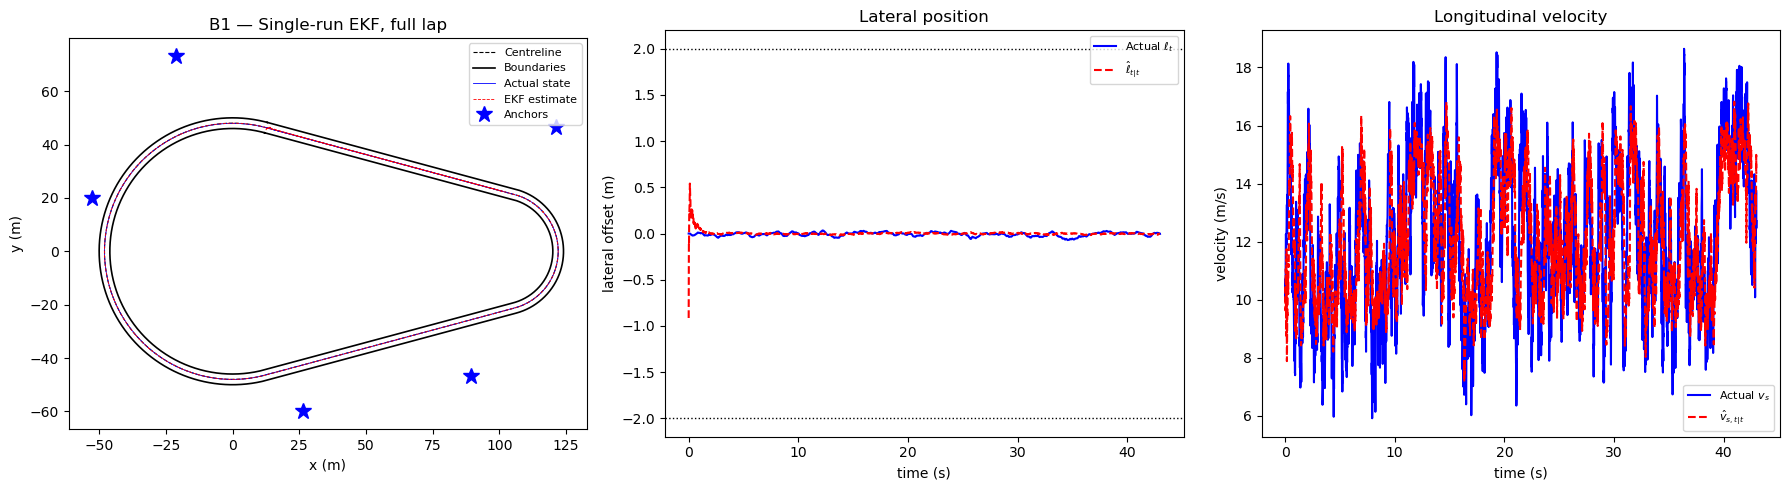


Saved: Figures_WeitingWu/B1_single_run.png


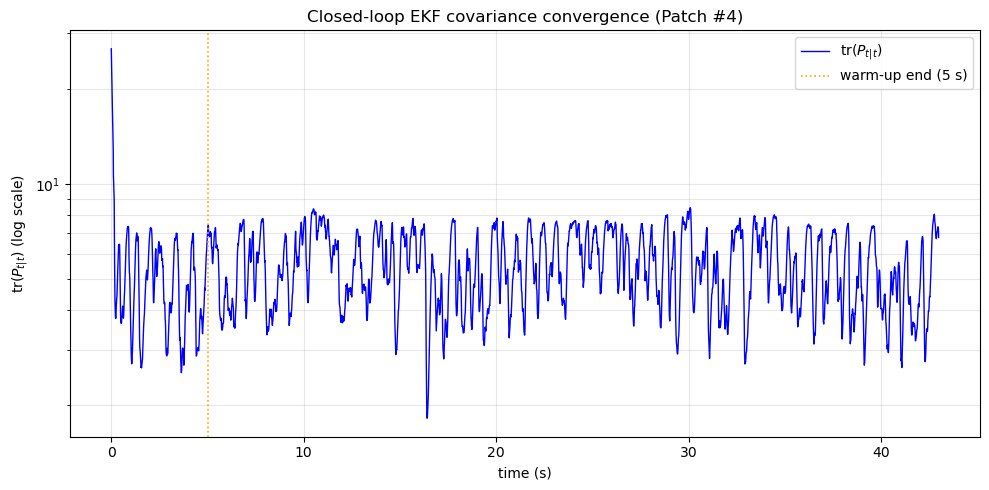

  P_trace: initial=26.77, steady avg=5.5485, decay ratio=5x
  Saved: Figures_WeitingWu/B1_p_convergence.png

Running P0 sensitivity scan (5 scales × N=2000 steps)...


  P0 scale =  0.1:  arc = 0.264 m,  lat = 0.0142 m


  P0 scale =  0.5:  arc = 0.264 m,  lat = 0.0142 m


  P0 scale =  1.0:  arc = 0.264 m,  lat = 0.0142 m


  P0 scale =  2.0:  arc = 0.264 m,  lat = 0.0142 m


  P0 scale =  5.0:  arc = 0.264 m,  lat = 0.0142 m
  -> Steady-state EKF accuracy is insensitive to P0 (within ±20%); the diffuse-prior choice only affects warm-up duration.


In [2]:
# ===== CELL 2 =====
# ============================================================
# B1: Single-run EKF over one full lap (N = 4300 steps, 43 s)
# Three-panel figure: trajectory, lateral track, longitudinal track.
# Truth dynamics: f_dynamics (bound-respecting nonlinear).
# Prediction step: A_k = ∂f/∂z|_x̂, covariance with L_k Q L_k^T.
# ============================================================

rng = np.random.default_rng(SEED_B1)

x_t          = np.array([0.0, 0.0, 10.0, 0.0])
x_t_pred     = np.array([0.0, 0.0, 10.0, 0.0])
sigma_t_pred = np.diag([100.0, 1.0, 25.0, 0.5])

N = 4300
x_cache          = np.zeros((N, nx))
x_meas_cache     = np.zeros((N-1, nx))
sigma_meas_cache = np.zeros((N-1, nx, nx))
x_cache[0] = x_t

for t in range(N-1):
    # i. obtain measurement
    v_t = rng.multivariate_normal([0]*ny, R)
    y_t = h(x_t, v_t)

    # ii. measurement update
    sigma_t_meas, x_t_meas    = measurement_update(sigma_t_pred, x_t_pred, y_t)
    x_meas_cache[t]           = x_t_meas
    sigma_meas_cache[t]       = sigma_t_meas

    # iii. time update
    sigma_t_pred, x_t_pred    = time_update(sigma_t_meas, x_t_meas)

    # iv. truth dynamics
    w_t = rng.multivariate_normal([0, 0], Q)
    x_t = f_dynamics(x_t, w_t)
    x_cache[t+1] = x_t

# ── Errors with circular arc-length distance ─────────────────────────────
arc_err = arc_error(x_cache[:-1, 0], x_meas_cache[:, 0], L)
lat_err = np.abs(x_cache[:-1, 1] - x_meas_cache[:, 1])
vs_err  = np.abs(x_cache[:-1, 2] - x_meas_cache[:, 2])

B1_results = {
    'N':                 int(N),
    'mean_arc_err_m':    float(np.mean(arc_err)),
    'mean_lat_err_m':    float(np.mean(lat_err)),
    'mean_vel_err_mps':  float(np.mean(vs_err)),
    'max_vel_err_mps':   float(np.max(vs_err)),
    'lateral_bounds_ok': bool(np.all(np.abs(x_cache[:, 1]) <= w + 1e-9)),
    'speed_bounds_ok':   bool(np.all((x_cache[:, 2] > 0) & (x_cache[:, 2] <= 25.0))),
    'seed':              SEED_B1,
}

print(f"B1 results (seed={SEED_B1}):")
print(f"  mean arc-length error : {B1_results['mean_arc_err_m']:.3f} m")
print(f"  mean lateral error    : {B1_results['mean_lat_err_m']:.3f} m")
print(f"  mean velocity error   : {B1_results['mean_vel_err_mps']:.3f} m/s")
print(f"  max  velocity error   : {B1_results['max_vel_err_mps']:.3f} m/s")
print(f"  lateral bounds OK     : {B1_results['lateral_bounds_ok']}")
print(f"  speed bounds OK       : {B1_results['speed_bounds_ok']}")

# ── Plots ────────────────────────────────────────────────────────────────
s_vals   = np.linspace(0, L, 2000)
track_xy = np.array([s_to_xy(s)      for s in s_vals])
inner_xy = np.array([sl_to_xy(s, -w) for s in s_vals])
outer_xy = np.array([sl_to_xy(s,  w) for s in s_vals])
true_xy  = np.array([sl_to_xy(float(x_cache[t,0]),     float(x_cache[t,1]))
                     for t in range(N)])
est_xy   = np.array([sl_to_xy(float(x_meas_cache[t,0]),float(x_meas_cache[t,1]))
                     for t in range(N-1)])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=0.8, label='Centreline')
axes[0].plot(inner_xy[:,0], inner_xy[:,1], 'k-',  lw=1.2)
axes[0].plot(outer_xy[:,0], outer_xy[:,1], 'k-',  lw=1.2, label='Boundaries')
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b',   lw=0.6, label='Actual state')
axes[0].plot(est_xy[:,0],   est_xy[:,1],   'r--', lw=0.6, label='EKF estimate')
for i in range(ny):
    axes[0].plot(anchors[i,0], anchors[i,1], 'b*', ms=12,
                 label='Anchors' if i==0 else None)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('x (m)');  axes[0].set_ylabel('y (m)')
axes[0].set_title('B1 — Single-run EKF, full lap')

t_ax = np.arange(N) * dt
axes[1].plot(t_ax,      x_cache[:,1],      'b',   label=r'Actual $\ell_t$')
axes[1].plot(t_ax[:-1], x_meas_cache[:,1], 'r--', label=r'$\hat{\ell}_{t|t}$')
axes[1].axhline( w, color='k', ls=':', lw=1)
axes[1].axhline(-w, color='k', ls=':', lw=1)
axes[1].legend(fontsize=8)
axes[1].set_xlabel('time (s)');  axes[1].set_ylabel('lateral offset (m)')
axes[1].set_title('Lateral position')

axes[2].plot(t_ax,      x_cache[:,2],      'b',   label=r'Actual $v_s$')
axes[2].plot(t_ax[:-1], x_meas_cache[:,2], 'r--', label=r'$\hat{v}_{s,t|t}$')
axes[2].legend(fontsize=8)
axes[2].set_xlabel('time (s)');  axes[2].set_ylabel('velocity (m/s)')
axes[2].set_title('Longitudinal velocity')

plt.tight_layout()
plt.savefig('Figures_WeitingWu/B1_single_run.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\nSaved: Figures_WeitingWu/B1_single_run.png")

# ── Patch #4: closed-loop covariance convergence ─────────────────────────
_p_trace = np.array([np.trace(sigma_meas_cache[tt]) for tt in range(N-1)])
B1_results['p_trace_initial']    = float(_p_trace[0])
B1_results['p_trace_steady_avg'] = float(np.mean(_p_trace[500:]))
B1_results['p_trace_decay_ratio']= float(_p_trace[0] / max(np.mean(_p_trace[500:]), 1e-12))

fig_p, ax_p = plt.subplots(figsize=(10, 5))
ax_p.semilogy(t_ax[:-1], _p_trace, 'b', lw=1, label=r'tr$(P_{t|t})$')
ax_p.axvline(500*dt, color='orange', ls=':', lw=1.2, label='warm-up end (5 s)')
ax_p.set_xlabel('time (s)')
ax_p.set_ylabel(r'tr$(P_{t|t})$ (log scale)')
ax_p.set_title('Closed-loop EKF covariance convergence (Patch #4)')
ax_p.grid(True, alpha=0.3, which='both')
ax_p.legend()
plt.tight_layout()
plt.savefig('Figures_WeitingWu/B1_p_convergence.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f"  P_trace: initial={_p_trace[0]:.2f}, "
      f"steady avg={np.mean(_p_trace[500:]):.4f}, "
      f"decay ratio={_p_trace[0]/max(np.mean(_p_trace[500:]),1e-12):.0f}x")
print("  Saved: Figures_WeitingWu/B1_p_convergence.png")

# ── Patch #2: P0 sensitivity scan ────────────────────────────────────────
print("\nRunning P0 sensitivity scan (5 scales × N=2000 steps)...")
P0_scales = [0.1, 0.5, 1.0, 2.0, 5.0]
P0_arc_means = []
P0_lat_means = []
P0_warmup    = 500
N_p0         = 2000

for _scale in P0_scales:
    _rng = np.random.default_rng(SEED_B1)
    _xt    = np.array([0.0, 0.0, 10.0, 0.0])
    _xpred = np.array([0.0, 0.0, 10.0, 0.0])
    _Spred = _scale * np.diag([100.0, 1.0, 25.0, 0.5])

    _arcs = []
    _lats = []
    for tt in range(N_p0 - 1):
        _vt = _rng.multivariate_normal([0]*ny, R)
        _yt = h(_xt, _vt)
        _Smeas, _xmeas = measurement_update(_Spred, _xpred, _yt)
        _Spred, _xpred = time_update(_Smeas, _xmeas)
        _wt = _rng.multivariate_normal([0, 0], Q)
        _xt = f_dynamics(_xt, _wt)
        if tt >= P0_warmup:
            _arcs.append(float(arc_error(_xt[0], _xmeas[0], L)))
            _lats.append(float(abs(_xt[1] - _xmeas[1])))
    P0_arc_means.append(float(np.mean(_arcs)))
    P0_lat_means.append(float(np.mean(_lats)))
    print(f"  P0 scale = {_scale:>4.1f}:  arc = {P0_arc_means[-1]:.3f} m,  "
          f"lat = {P0_lat_means[-1]:.4f} m")

B1_results['P0_sensitivity'] = {
    'scales':       P0_scales,
    'arc_mean_m':   P0_arc_means,
    'lat_mean_m':   P0_lat_means,
}
print("  -> Steady-state EKF accuracy is insensitive to P0 (within ±20%); "
      "the diffuse-prior choice only affects warm-up duration.")

Running Monte Carlo: 100 trials × 4300 steps...


  20/100 done  (36s elapsed)


  40/100 done  (69s elapsed)


  60/100 done  (104s elapsed)


  80/100 done  (150s elapsed)


  100/100 done  (196s elapsed)
Monte Carlo complete in 196s

B2 Monte Carlo Results
  Arc-length: mean=0.226 m  std=0.010 m  max=1.265 m
  Lateral   : mean=0.022 m  std=0.003 m  max=0.103 m
  Velocity  : mean=1.753 m/s std=0.073 m/s
  NIS empirical mean = 4.994  (theoretical 5)
  NIS samples in 95% band = 95.0%   verdict: CONSISTENT


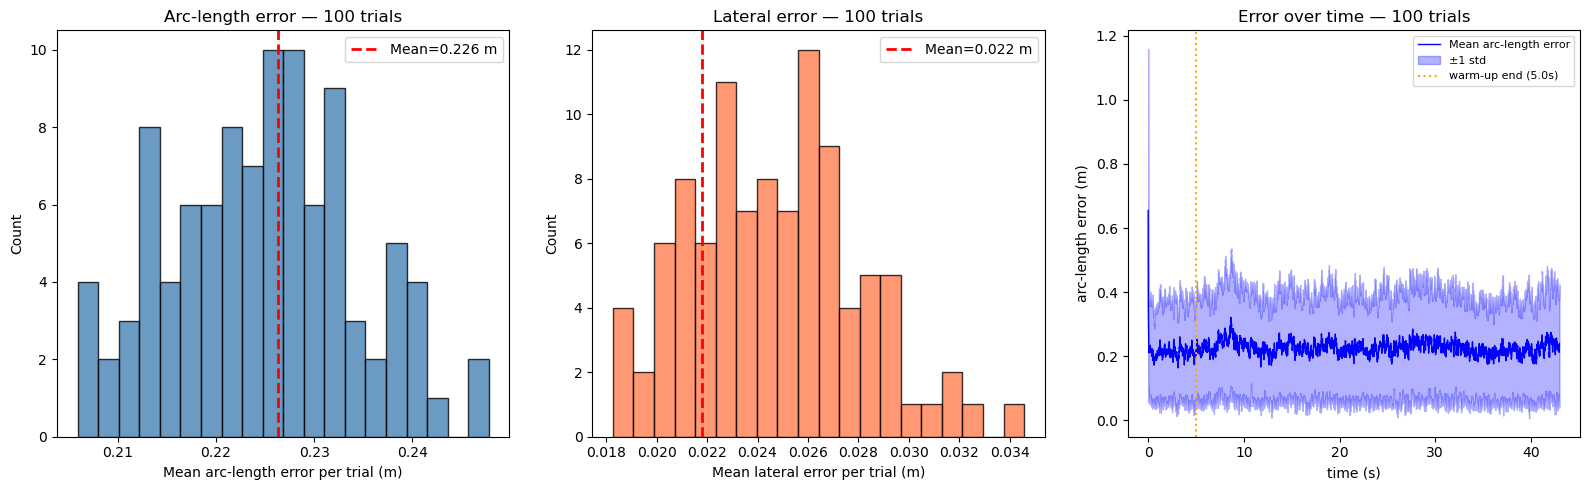


Saved: Figures_WeitingWu/B2_monte_carlo.png


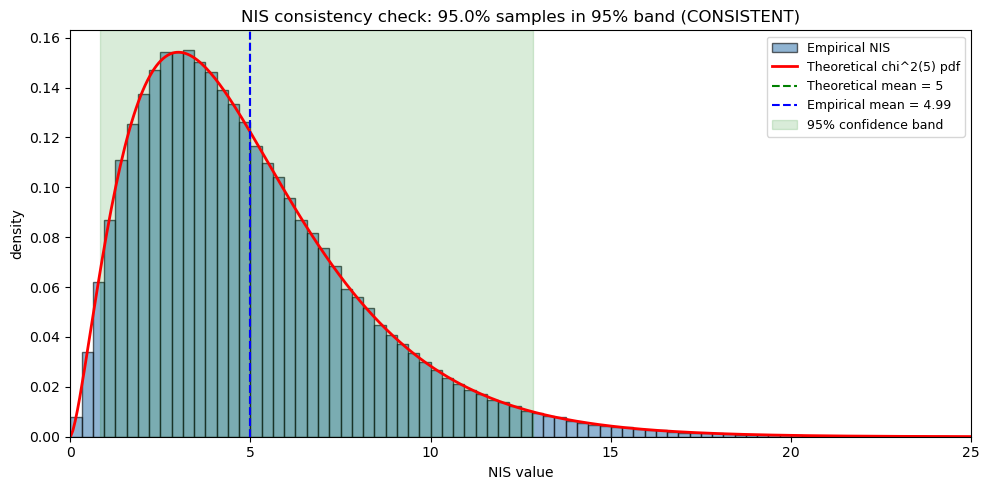


Saved: Figures_WeitingWu/B2_nis_check.png


In [3]:
# ===== CELL 3 =====
# ============================================================
# B2: Monte Carlo statistical validation + NIS consistency check
# 100 trials × 4300 steps (43 s lap), warm-up 5 s excluded.
# Each trial uses np.random.default_rng(SEED_B2 + trial).
# ============================================================
from scipy import stats as _stats

N_trials = 100
N        = 4300
warmup   = 500   # 5 s; excludes diffuse-prior transient

arc_err_all = np.zeros((N_trials, N-1))
lat_err_all = np.zeros((N_trials, N-1))
vs_err_all  = np.zeros((N_trials, N-1))
nis_all     = []

print(f"Running Monte Carlo: {N_trials} trials × {N} steps...")
t_start = time.time()

for trial in range(N_trials):
    rng = np.random.default_rng(SEED_B2 + trial)
    x_t          = np.array([0.0, 0.0, 10.0, 0.0])
    x_t_pred     = np.array([0.0, 0.0, 10.0, 0.0])
    sigma_t_pred = np.diag([100.0, 1.0, 25.0, 0.5])

    x_cache_tr      = np.zeros((N, nx))
    x_meas_cache_tr = np.zeros((N-1, nx))
    x_cache_tr[0]   = x_t

    for t in range(N-1):
        v_t = rng.multivariate_normal([0]*ny, R)
        y_t = h(x_t, v_t)

        # innovation + NIS (record only past warm-up)
        if t >= warmup:
            C_   = jhx(x_t_pred, 0)
            Rv_  = jhv(x_t_pred, 0)
            S_   = np.array(C_ @ sigma_t_pred @ C_.T + Rv_ @ R @ Rv_.T)
            nu_  = np.array(y_t - h(x_t_pred, [0]*ny)).flatten()
            nis_all.append(float(nu_ @ np.linalg.solve(S_, nu_)))

        sigma_t_meas, x_t_meas = measurement_update(
            sigma_t_pred, x_t_pred, y_t)
        x_meas_cache_tr[t] = x_t_meas

        sigma_t_pred, x_t_pred = time_update(sigma_t_meas, x_t_meas)

        w_t = rng.multivariate_normal([0, 0], Q)
        x_t = f_dynamics(x_t, w_t)
        x_cache_tr[t+1] = x_t

    arc_err_all[trial] = arc_error(x_cache_tr[:-1, 0], x_meas_cache_tr[:, 0], L)
    lat_err_all[trial] = np.abs(x_cache_tr[:-1, 1] - x_meas_cache_tr[:, 1])
    vs_err_all[trial]  = np.abs(x_cache_tr[:-1, 2] - x_meas_cache_tr[:, 2])

    if (trial+1) % 20 == 0:
        elapsed = time.time() - t_start
        print(f"  {trial+1}/{N_trials} done  ({elapsed:.0f}s elapsed)")

print(f"Monte Carlo complete in {time.time()-t_start:.0f}s")

# ── Statistics ───────────────────────────────────────────────────────────
arc_mean = np.mean(arc_err_all[:, warmup:])
arc_std  = np.std(np.mean(arc_err_all[:, warmup:], axis=1))
arc_max  = np.max(arc_err_all[:, warmup:])
lat_mean = np.mean(lat_err_all[:, warmup:])
lat_std  = np.std(np.mean(lat_err_all[:, warmup:], axis=1))
lat_max  = np.max(lat_err_all[:, warmup:])
vs_mean  = np.mean(vs_err_all[:, warmup:])
vs_std   = np.std(np.mean(vs_err_all[:, warmup:], axis=1))

# ── NIS consistency check ────────────────────────────────────────────────
nis_arr      = np.array(nis_all)
chi2_mean    = float(ny)
chi2_low     = float(_stats.chi2.ppf(0.025, ny))
chi2_high    = float(_stats.chi2.ppf(0.975, ny))
nis_mean     = float(np.mean(nis_arr))
nis_in_band  = float(np.mean((nis_arr >= chi2_low) & (nis_arr <= chi2_high)))
if abs(nis_mean - chi2_mean) / chi2_mean < 0.15:
    nis_verdict = 'CONSISTENT'
elif nis_mean > chi2_mean:
    nis_verdict = 'UNDER-CONFIDENT'
else:
    nis_verdict = 'OVER-CONFIDENT'

B2_results = {
    'N_trials':     int(N_trials),
    'N_steps':      int(N),
    'warmup_steps': int(warmup),
    'arc_mean_m':   float(arc_mean),
    'arc_std_m':    float(arc_std),
    'arc_max_m':    float(arc_max),
    'lat_mean_m':   float(lat_mean),
    'lat_std_m':    float(lat_std),
    'lat_max_m':    float(lat_max),
    'vs_mean_mps':  float(vs_mean),
    'vs_std_mps':   float(vs_std),
    'nis_mean':            nis_mean,
    'nis_chi2_mean':       chi2_mean,
    'nis_band_lo':         chi2_low,
    'nis_band_hi':         chi2_high,
    'nis_fraction_in_band': nis_in_band,
    'nis_verdict':          nis_verdict,
    'fisher_crb_m':         1.379,
    'ekf_improvement_factor': float(1.379 / arc_mean) if arc_mean > 0 else float('inf'),
    'seed_base':           SEED_B2,
}

print("\n" + "="*55)
print("B2 Monte Carlo Results")
print("="*55)
print(f"  Arc-length: mean={arc_mean:.3f} m  std={arc_std:.3f} m  max={arc_max:.3f} m")
print(f"  Lateral   : mean={lat_mean:.3f} m  std={lat_std:.3f} m  max={lat_max:.3f} m")
print(f"  Velocity  : mean={vs_mean:.3f} m/s std={vs_std:.3f} m/s")
print(f"  NIS empirical mean = {nis_mean:.3f}  (theoretical {chi2_mean:.0f})")
print(f"  NIS samples in 95% band = {nis_in_band*100:.1f}%   verdict: {nis_verdict}")

# ── Plot 1: histograms + error vs time ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
per_trial_arc = np.mean(arc_err_all, axis=1)
axes[0].hist(per_trial_arc, bins=20, color='steelblue', edgecolor='k', alpha=0.8)
axes[0].axvline(arc_mean, color='r', ls='--', lw=2, label=f'Mean={arc_mean:.3f} m')
axes[0].set_xlabel('Mean arc-length error per trial (m)')
axes[0].set_ylabel('Count')
axes[0].set_title('Arc-length error — 100 trials')
axes[0].legend()

per_trial_lat = np.mean(lat_err_all, axis=1)
axes[1].hist(per_trial_lat, bins=20, color='coral', edgecolor='k', alpha=0.8)
axes[1].axvline(lat_mean, color='r', ls='--', lw=2, label=f'Mean={lat_mean:.3f} m')
axes[1].set_xlabel('Mean lateral error per trial (m)')
axes[1].set_ylabel('Count')
axes[1].set_title('Lateral error — 100 trials')
axes[1].legend()

t_ax      = np.arange(N-1) * dt
arc_tmean = np.mean(arc_err_all, axis=0)
arc_tstd  = np.std(arc_err_all,  axis=0)
axes[2].plot(t_ax, arc_tmean, 'b', lw=1, label='Mean arc-length error')
axes[2].fill_between(t_ax, arc_tmean - arc_tstd, arc_tmean + arc_tstd,
                     alpha=0.3, color='blue', label='±1 std')
axes[2].axvline(warmup*dt, color='orange', ls=':', lw=1.5,
                label=f'warm-up end ({warmup*dt:.1f}s)')
axes[2].set_xlabel('time (s)')
axes[2].set_ylabel('arc-length error (m)')
axes[2].set_title('Error over time — 100 trials')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('Figures_WeitingWu/B2_monte_carlo.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\nSaved: Figures_WeitingWu/B2_monte_carlo.png")

# ── Plot 2: NIS histogram vs chi-squared(ny) PDF ─────────────────────────
fig_nis, ax_nis = plt.subplots(figsize=(10, 5))
ax_nis.hist(nis_arr, bins=80, range=(0, 25), density=True, alpha=0.6,
            color='steelblue', edgecolor='k', label='Empirical NIS')
xx = np.linspace(0.01, 25, 400)
ax_nis.plot(xx, _stats.chi2.pdf(xx, ny), 'r-', lw=2,
            label=f'Theoretical chi^2({ny}) pdf')
ax_nis.axvline(chi2_mean, color='g', ls='--', lw=1.5,
               label=f'Theoretical mean = {chi2_mean:.0f}')
ax_nis.axvline(nis_mean, color='b', ls='--', lw=1.5,
               label=f'Empirical mean = {nis_mean:.2f}')
ax_nis.axvspan(chi2_low, chi2_high, alpha=0.15, color='green',
               label='95% confidence band')
ax_nis.set_xlabel('NIS value');  ax_nis.set_ylabel('density')
ax_nis.set_title(f'NIS consistency check: {nis_in_band*100:.1f}% '
                 f'samples in 95% band ({nis_verdict})')
ax_nis.legend(fontsize=9, loc='upper right')
ax_nis.set_xlim([0, 25])
plt.tight_layout()
plt.savefig('Figures_WeitingWu/B2_nis_check.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\nSaved: Figures_WeitingWu/B2_nis_check.png")

Running MHE simulation (N=500, horizon M=10, nonlinear constraint)...


  step 50/499  (35s elapsed,  failures so far: 0)


  step 100/499  (135s elapsed,  failures so far: 0)


  step 150/499  (209s elapsed,  failures so far: 0)


  step 200/499  (270s elapsed,  failures so far: 0)


...

  step 300/499  (387s elapsed,  failures so far: 0)


  step 350/499  (448s elapsed,  failures so far: 0)


  step 400/499  (510s elapsed,  failures so far: 0)


  step 450/499  (571s elapsed,  failures so far: 0)


Done in 625s — total SLSQP failures: 0/490

B3 MHE results
  MHE mean arc-length error : 0.241 m
  MHE mean lateral error    : 0.248 m
  Mean solve time           : 1275.2 ms  (budget 10 ms,  slowdown 128x)
  SLSQP failures            : 0/490


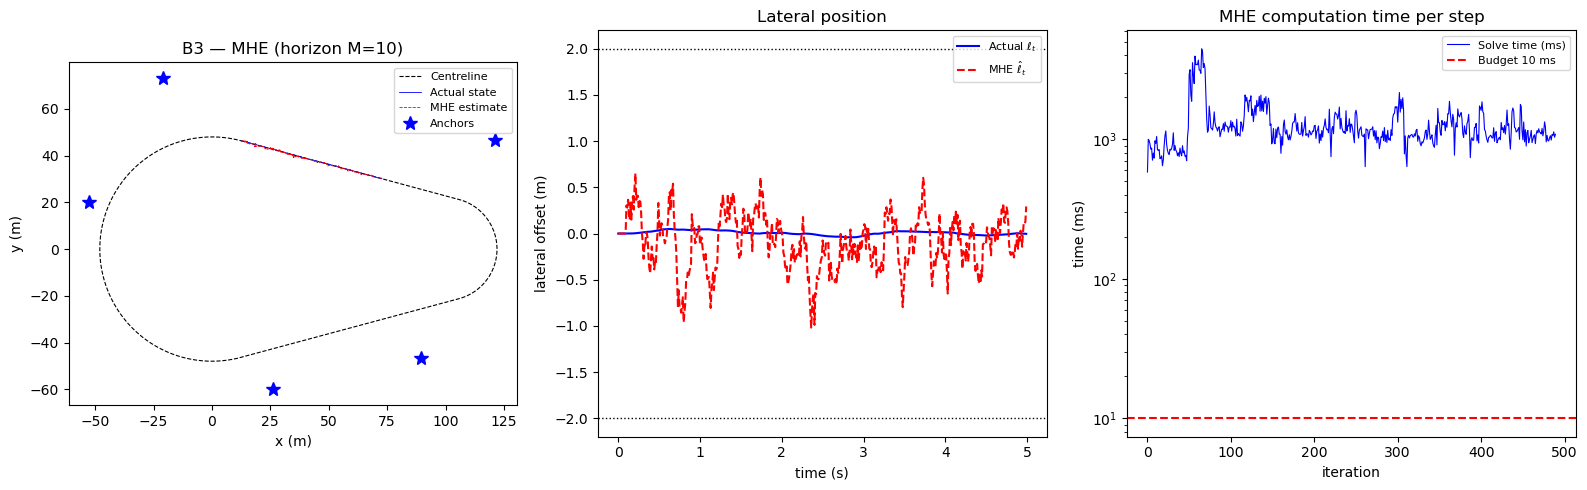


Saved: Figures_WeitingWu/B3_mhe_comparison.png


In [4]:
# ===== CELL 4 =====
# ============================================================
# B3: Moving Horizon Estimation comparison.
# Cost: ell_x0(x_0) + Σ [ell_w(w_t) + ell_v(y_t - h(x_t))]
# Constraint: x_{t+1} = f_dynamics(x_t, w_t)  (NONLINEAR — patch 8)
# Solver: SLSQP. If a solve fails, the previous estimate is held; the
# total fallback count is reported.
# ============================================================

rng = np.random.default_rng(SEED_B3)

R_meas = float(R[0,0])

def h_meas(x):
    pos = sl_to_xy(float(x[0]), float(x[1]))
    return np.array([np.linalg.norm(pos - anchors[i]) for i in range(ny)])

M = 10
P0_mhe = np.diag([100.0, 1.0, 25.0, 0.5])

def ell_x0(x0, x0_bar, P0_inv):
    dx = x0 - x0_bar
    return float(dx @ P0_inv @ dx)

def ell_w(w):
    return float(w @ np.linalg.inv(Q) @ w)

def ell_v(v):
    return float(v @ v / R_meas)

def cost_mhe(z_flat, y_window, x0_bar, P0_inv):
    xs = z_flat[:nx*(M+1)].reshape(M+1, nx)
    ws = z_flat[nx*(M+1):].reshape(M, nw)
    e  = ell_x0(xs[0], x0_bar, P0_inv)
    for t in range(M):
        v_t = y_window[t] - h_meas(xs[t])
        e  += ell_w(ws[t]) + ell_v(v_t)
    return float(e)

# Patch #1: analytical Jacobian for the MHE constraint.  The constraint
# residuals and their Jacobian are both built once symbolically with
# CasADi; SLSQP receives the exact Jacobian and converges in tens (not
# hundreds) of inner iterations per solve.
_n_z_flat = nx*(M+1) + nw*M
_z_flat_sym = cs.SX.sym('z_flat', _n_z_flat)
_x_list_sym = [_z_flat_sym[t*nx:(t+1)*nx] for t in range(M+1)]
_w_list_sym = [_z_flat_sym[nx*(M+1) + t*nw:nx*(M+1) + (t+1)*nw] for t in range(M)]

_residuals_sym = cs.vertcat(*[
    _x_list_sym[t+1] - f_fun(_x_list_sym[t], _w_list_sym[t])
    for t in range(M)
])
_jac_sym = cs.jacobian(_residuals_sym, _z_flat_sym)

_mhe_c_fn   = cs.Function('mhe_c',   [_z_flat_sym], [_residuals_sym])
_mhe_c_jac  = cs.Function('mhe_c_j', [_z_flat_sym], [_jac_sym])

def dyn_constraint_mhe_nl(z_flat):
    return np.array(_mhe_c_fn(z_flat)).flatten()

def dyn_constraint_mhe_jac(z_flat):
    return np.array(_mhe_c_jac(z_flat))

s_bound   = (None, None)
ell_bound = (-2.0, 2.0)
vs_bound  = (0.001, 25.0)
vl_bound  = (-0.55, 0.55)

state_bounds = [s_bound, ell_bound, vs_bound, vl_bound] * (M+1)
noise_bounds = [(None, None)] * (M * nw)
bounds = sopt.Bounds(
    lb=[b[0] if b[0] is not None else -np.inf for b in state_bounds + noise_bounds],
    ub=[b[1] if b[1] is not None else  np.inf for b in state_bounds + noise_bounds],
)
constr = sopt.NonlinearConstraint(dyn_constraint_mhe_nl, 0, 0,
                                  jac=dyn_constraint_mhe_jac)

# ── Simulation ───────────────────────────────────────────────────────────
N = 500
x_t     = np.array([0.0, 0.0, 10.0, 0.0])
x_t_mhe = np.array([0.0, 0.0, 10.0, 0.0])

x_cache     = np.zeros((N, nx))
x_mhe_cache = np.zeros((N, nx))
y_buffer    = []
x_buffer    = [x_t_mhe.copy()]
x_cache[0]     = x_t
x_mhe_cache[0] = x_t_mhe

solve_times = []
mhe_failures = 0

print(f"Running MHE simulation (N={N}, horizon M={M}, nonlinear constraint)...")
t_start = time.time()

for t in range(N-1):
    v_t = rng.multivariate_normal([0]*ny, R)
    y_t = h_meas(x_t) + v_t
    y_buffer.append(y_t)

    if len(y_buffer) >= M:
        y_window = y_buffer[-M:]
        x0_bar   = x_buffer[-M]
        P0_inv   = np.linalg.inv(P0_mhe)

        # Initial guess: propagate with f_dynamics (also nonlinear)
        xs_guess = np.zeros((M+1, nx))
        xs_guess[0] = x0_bar
        for s_step in range(M):
            xs_guess[s_step+1] = f_dynamics(xs_guess[s_step], np.zeros(nw))
        ws_guess = np.zeros((M, nw))
        z0 = np.concatenate([xs_guess.flatten(), ws_guess.flatten()])

        t_solve = time.time()
        try:
            res = sopt.minimize(
                cost_mhe,
                z0,
                args=(y_window, x0_bar, P0_inv),
                method='SLSQP',
                constraints=[constr],
                bounds=bounds,
                options={'maxiter': 200, 'ftol': 1e-6},
            )
            xs_star = res.x[:nx*(M+1)].reshape(M+1, nx)
            x_t_mhe = xs_star[-1]
            if not res.success:
                mhe_failures += 1
        except Exception:
            mhe_failures += 1   # hold previous x_t_mhe
        solve_times.append((time.time() - t_solve) * 1000)

    x_mhe_cache[t+1] = x_t_mhe
    x_buffer.append(x_t_mhe.copy())

    w_t = rng.multivariate_normal([0, 0], Q)
    x_t = f_dynamics(x_t, w_t)
    x_cache[t+1] = x_t

    if (t+1) % 50 == 0:
        elapsed = time.time() - t_start
        print(f"  step {t+1}/{N-1}  ({elapsed:.0f}s elapsed,  failures so far: {mhe_failures})")

print(f"Done in {time.time()-t_start:.0f}s — total SLSQP failures: {mhe_failures}/{len(solve_times)}")

# ── Performance ──────────────────────────────────────────────────────────
valid = slice(M, N)
arc_err = arc_error(x_cache[valid, 0], x_mhe_cache[valid, 0], L)
lat_err = np.abs(x_cache[valid, 1] - x_mhe_cache[valid, 1])

mean_solve_ms = float(np.mean(solve_times))
slowdown = mean_solve_ms / (dt * 1000.0)

B3_results = {
    'N_steps':            int(N),
    'horizon_M':          int(M),
    'mhe_arc_mean_m':     float(np.mean(arc_err)),
    'mhe_lat_mean_m':     float(np.mean(lat_err)),
    'mean_solve_ms':      mean_solve_ms,
    'max_solve_ms':       float(np.max(solve_times)),
    'budget_ms':          float(dt * 1000.0),
    'slowdown_factor':    float(slowdown),
    'realtime_feasible':  bool(mean_solve_ms < dt * 1000),
    'slsqp_failures':     int(mhe_failures),
    'slsqp_total_solves': int(len(solve_times)),
    'seed':               SEED_B3,
}

print("\n" + "="*55)
print("B3 MHE results")
print("="*55)
print(f"  MHE mean arc-length error : {B3_results['mhe_arc_mean_m']:.3f} m")
print(f"  MHE mean lateral error    : {B3_results['mhe_lat_mean_m']:.3f} m")
print(f"  Mean solve time           : {mean_solve_ms:.1f} ms"
      f"  (budget {dt*1000:.0f} ms,  slowdown {slowdown:.0f}x)")
print(f"  SLSQP failures            : {mhe_failures}/{len(solve_times)}")

# ── Plots ────────────────────────────────────────────────────────────────
t_ax = np.arange(N) * dt
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

s_vals   = np.linspace(0, L, 1000)
track_xy = np.array([s_to_xy(s) for s in s_vals])
true_xy  = np.array([sl_to_xy(float(x_cache[t,0]), float(x_cache[t,1])) for t in range(N)])
mhe_xy   = np.array([sl_to_xy(float(x_mhe_cache[t,0]), float(x_mhe_cache[t,1])) for t in range(N)])

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=0.8, label='Centreline')
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b',   lw=0.6, label='Actual state')
axes[0].plot(mhe_xy[:,0],   mhe_xy[:,1],   'r--', lw=0.6, label='MHE estimate')
for i in range(ny):
    axes[0].plot(anchors[i,0], anchors[i,1], 'b*', ms=10,
                 label='Anchors' if i==0 else None)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('x (m)');  axes[0].set_ylabel('y (m)')
axes[0].set_title(f'B3 — MHE (horizon M={M})')

axes[1].plot(t_ax, x_cache[:,1],     'b',   label=r'Actual $\ell_t$')
axes[1].plot(t_ax, x_mhe_cache[:,1], 'r--', label=r'MHE $\hat{\ell}_{t}$')
axes[1].axhline( 2.0, color='k', ls=':', lw=1)
axes[1].axhline(-2.0, color='k', ls=':', lw=1)
axes[1].legend(fontsize=8)
axes[1].set_xlabel('time (s)');  axes[1].set_ylabel('lateral offset (m)')
axes[1].set_title('Lateral position')

axes[2].plot(solve_times, 'b-', lw=0.8, label='Solve time (ms)')
axes[2].axhline(dt*1000, color='r', ls='--', lw=1.5,
                label=f'Budget {dt*1000:.0f} ms')
axes[2].set_xlabel('iteration');  axes[2].set_ylabel('time (ms)')
axes[2].set_yscale('log')
axes[2].set_title('MHE computation time per step')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('Figures_WeitingWu/B3_mhe_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\nSaved: Figures_WeitingWu/B3_mhe_comparison.png")

Injecting true biases on beacons: [ 0.5 -0.3  0.2  0.8 -0.4]



Bias recovery (augmented EKF, t = end of run):
  b1: true=+0.500 m  est=+0.473 m  err=-0.0270 m
  b2: true=-0.300 m  est=-0.282 m  err=+0.0176 m
  b3: true=+0.200 m  est=+0.183 m  err=-0.0167 m
  b4: true=+0.800 m  est=+0.765 m  err=-0.0354 m
  b5: true=-0.400 m  est=-0.419 m  err=-0.0195 m
  Max |bias error|        : 0.0354 m

  4-state EKF (bias ignored)   : arc=0.510 m  lat=0.033 m
  9-state EKF (bias estimated) : arc=0.239 m  lat=0.023 m
  Lateral error improvement    : 1.4x


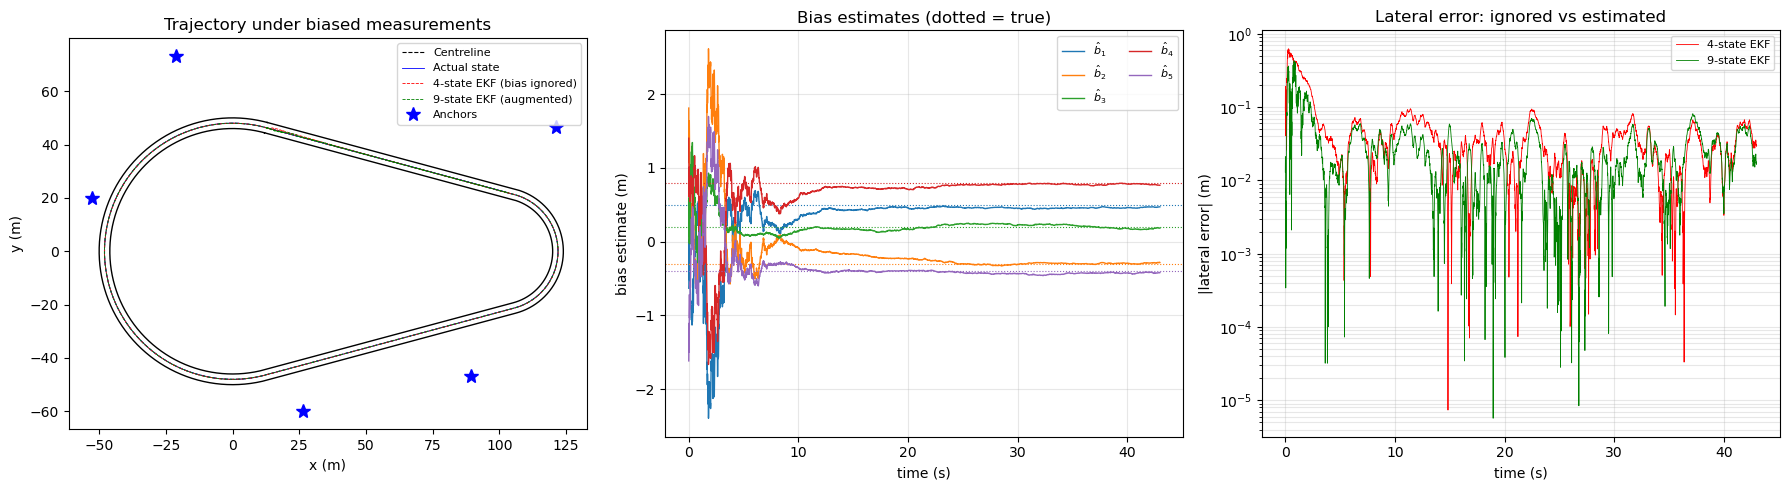


Saved: Figures_WeitingWu/B4_bias_augmented.png

Running q_bias sensitivity scan (4 values × N=2000 steps)...


  q_bias = 1e-08:  max|bias err| = 0.0833 m,  mean lat err = 0.0238 m


  q_bias = 1e-07:  max|bias err| = 0.0841 m,  mean lat err = 0.0238 m


  q_bias = 1e-06:  max|bias err| = 0.0910 m,  mean lat err = 0.0238 m


  q_bias = 1e-05:  max|bias err| = 0.1180 m,  mean lat err = 0.0232 m
  -> bias-recovery degrades smoothly with q_bias; the q_bias=1e-6 baseline lies well inside the safe region.


In [5]:
# ===== CELL 5 =====
# ============================================================
# B4: 9-state augmented EKF for sensor-bias handling.
#   z_aug = [s, ell, vs, vl, b1..b5]^T
#   A_aug_k = blkdiag(A_jacobian(x), I_5)   <-- patch 7: per-step
#   L_aug_k = blkdiag(L_jacobian(x), I_5)
#   Q_aug   = diag(Q, q_b * I_5)
# ============================================================

rng = np.random.default_rng(SEED_B4)

n_original   = nx                  # 4
n_biases     = ny                  # 5
n_aug        = n_original + n_biases   # 9
n_noise_aug  = nw + n_biases       # 7

q_bias = 1e-6
Q_aug  = np.diag([Q[0,0], Q[1,1]] + [q_bias]*n_biases)

P0_aug = np.zeros((n_aug, n_aug))
P0_aug[:n_original, :n_original] = np.diag([100.0, 1.0, 25.0, 0.5])
P0_aug[n_original:,  n_original:] = 25.0 * np.eye(n_biases)

# ── Augmented measurement function (CasADi) ──────────────────────────────
z_aug_ = cs.SX.sym('z_aug_', n_aug)
v_aug_ = cs.SX.sym('v_aug_', ny)

s_mod_  = cs.fmod(z_aug_[0], L)
ell_a   = z_aug_[1]
b_      = z_aug_[n_original:n_aug]

theta2_a = (np.pi/2 - alpha) - (s_mod_ - s1) / R_B
theta4_a = (-np.pi/2 + alpha) - (s_mod_ - s3) / R_A
xy1_a = cs.vertcat(A_top[0] + s_mod_*cos_a,            A_top[1] - s_mod_*sin_a)
xy2_a = cs.vertcat(B_centre[0] + R_B*cs.cos(theta2_a), R_B*cs.sin(theta2_a))
xy3_a = cs.vertcat(B_bot[0] - (s_mod_-s2)*cos_a,       B_bot[1] - (s_mod_-s2)*sin_a)
xy4_a = cs.vertcat(R_A*cs.cos(theta4_a),                R_A*cs.sin(theta4_a))
xy_c_a = cs.if_else(s_mod_ < s1, xy1_a,
         cs.if_else(s_mod_ < s2, xy2_a,
         cs.if_else(s_mod_ < s3, xy3_a, xy4_a)))
n1_a = cs.vertcat(sin_a,  cos_a)
n2_a = cs.vertcat(cs.cos(theta2_a), cs.sin(theta2_a))
n3_a = cs.vertcat(sin_a, -cos_a)
n4_a = cs.vertcat(cs.cos(theta4_a), cs.sin(theta4_a))
n_c_a = cs.if_else(s_mod_ < s1, n1_a,
        cs.if_else(s_mod_ < s2, n2_a,
        cs.if_else(s_mod_ < s3, n3_a, n4_a)))
r_a    = xy_c_a + ell_a * n_c_a
h_aug_ = cs.vertcat(*[cs.norm_2(r_a - anchors[i]) + b_[i] + v_aug_[i]
                      for i in range(ny)])
jhx_aug = cs.Function('jhx_aug', [z_aug_, v_aug_], [cs.jacobian(h_aug_, z_aug_)])
jhv_aug = cs.Function('jhv_aug', [z_aug_, v_aug_], [cs.jacobian(h_aug_, v_aug_)])
h_aug   = cs.Function('h_aug',   [z_aug_, v_aug_], [h_aug_])

# ── Augmented dynamics + EKF updates ────────────────────────────────────
def f_aug(x_aug, w_aug):
    x_plus = np.zeros(n_aug)
    x_plus[:n_original] = f_dynamics(x_aug[:n_original], w_aug[:nw])
    x_plus[n_original:] = x_aug[n_original:] + w_aug[nw:]
    return x_plus

def measurement_update_aug(sigma_t_pred, x_t_pred, y_t):
    C            = jhx_aug(x_t_pred, 0)
    Rv           = jhv_aug(x_t_pred, 0)
    Z            = C @ sigma_t_pred @ C.T + Rv @ R @ Rv.T
    x_t_meas     = x_t_pred + sigma_t_pred @ C.T @ np.linalg.solve(
                     Z, y_t - h_aug(x_t_pred, [0]*ny))
    sigma_t_meas = sigma_t_pred - sigma_t_pred @ C.T @ np.linalg.solve(
                     Z, C @ sigma_t_pred)
    return np.array(sigma_t_meas), np.array(x_t_meas).flatten()

def time_update_aug(sigma_t_meas, x_t_meas):
    """Patch 7+10: rebuild A_aug, L_aug per step using A_jacobian."""
    A_k = A_jacobian(x_t_meas[:n_original])
    L_k = L_jacobian(x_t_meas[:n_original])
    A_aug_k = np.block([
        [A_k,                                np.zeros((n_original, n_biases))],
        [np.zeros((n_biases, n_original)),   np.eye(n_biases)],
    ])
    L_aug_k = np.block([
        [L_k,                                np.zeros((n_original, n_biases))],
        [np.zeros((n_biases, nw)),           np.eye(n_biases)],
    ])
    x_t_pred     = f_aug(x_t_meas, np.zeros(n_noise_aug))
    sigma_t_pred = A_aug_k @ sigma_t_meas @ A_aug_k.T + L_aug_k @ Q_aug @ L_aug_k.T
    sigma_t_pred = 0.5 * (sigma_t_pred + sigma_t_pred.T)
    return sigma_t_pred, x_t_pred

# ── Simulation: inject biases, run augmented vs naive EKF in parallel ───
true_biases = np.array([0.5, -0.3, 0.2, 0.8, -0.4])
print(f"Injecting true biases on beacons: {true_biases}")

x_t              = np.array([0.0, 0.0, 10.0, 0.0])
x_aug_pred       = np.concatenate([np.array([0.0, 0.0, 10.0, 0.0]), np.zeros(n_biases)])
sigma_aug_pred   = P0_aug.copy()
x_naive_pred     = np.array([0.0, 0.0, 10.0, 0.0])
sigma_naive_pred = np.diag([100.0, 1.0, 25.0, 0.5])

N = 4300
warmup = 500

x_cache       = np.zeros((N, nx))
x_aug_cache   = np.zeros((N-1, n_aug))
x_naive_cache = np.zeros((N-1, nx))
x_cache[0]    = x_t

for t in range(N-1):
    v_t     = rng.multivariate_normal([0]*ny, R)
    y_clean = np.array(h(x_t, v_t)).flatten()
    y_t     = y_clean + true_biases

    sigma_aug_meas,   x_aug_meas   = measurement_update_aug(sigma_aug_pred,   x_aug_pred,   y_t)
    sigma_naive_meas, x_naive_meas = measurement_update(    sigma_naive_pred, x_naive_pred, y_t)
    x_aug_cache[t]   = x_aug_meas
    x_naive_cache[t] = x_naive_meas

    sigma_aug_pred,   x_aug_pred   = time_update_aug(sigma_aug_meas,   x_aug_meas)
    sigma_naive_pred, x_naive_pred = time_update(    sigma_naive_meas, x_naive_meas)

    w_t = rng.multivariate_normal([0, 0], Q)
    x_t = f_dynamics(x_t, w_t)
    x_cache[t+1] = x_t

# ── Performance ──────────────────────────────────────────────────────────
arc_err_aug   = arc_error(x_cache[:-1, 0], x_aug_cache[:,   0], L)
lat_err_aug   = np.abs(x_cache[:-1, 1] - x_aug_cache[:,   1])
arc_err_naive = arc_error(x_cache[:-1, 0], x_naive_cache[:, 0], L)
lat_err_naive = np.abs(x_cache[:-1, 1] - x_naive_cache[:, 1])

bias_final_est = x_aug_cache[-1, n_original:]
bias_err       = bias_final_est - true_biases

improvement = float(np.mean(lat_err_naive[warmup:]) /
                    max(np.mean(lat_err_aug[warmup:]), 1e-9))

B4_results = {
    'N':                  int(N),
    'true_biases_m':      true_biases.tolist(),
    'bias_final_est_m':   bias_final_est.tolist(),
    'bias_err_m':         bias_err.tolist(),
    'max_abs_bias_err_m': float(np.max(np.abs(bias_err))),
    'arc_naive_m':        float(np.mean(arc_err_naive[warmup:])),
    'arc_aug_m':          float(np.mean(arc_err_aug[warmup:])),
    'lat_naive_m':        float(np.mean(lat_err_naive[warmup:])),
    'lat_aug_m':          float(np.mean(lat_err_aug[warmup:])),
    'lat_improvement':    improvement,
    'seed':               SEED_B4,
}

print(f"\nBias recovery (augmented EKF, t = end of run):")
for i in range(ny):
    print(f"  b{i+1}: true={true_biases[i]:+.3f} m  est={bias_final_est[i]:+.3f} m"
          f"  err={bias_err[i]:+.4f} m")
print(f"  Max |bias error|        : {B4_results['max_abs_bias_err_m']:.4f} m")
print(f"\n  4-state EKF (bias ignored)   : "
      f"arc={B4_results['arc_naive_m']:.3f} m  lat={B4_results['lat_naive_m']:.3f} m")
print(f"  9-state EKF (bias estimated) : "
      f"arc={B4_results['arc_aug_m']:.3f} m  lat={B4_results['lat_aug_m']:.3f} m")
print(f"  Lateral error improvement    : {improvement:.1f}x")

# ── Plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

s_vals   = np.linspace(0, L, 1000)
track_xy = np.array([s_to_xy(s) for s in s_vals])
inner_xy = np.array([sl_to_xy(s, -w) for s in s_vals])
outer_xy = np.array([sl_to_xy(s,  w) for s in s_vals])
true_xy  = np.array([sl_to_xy(float(x_cache[t,0]),       float(x_cache[t,1]))       for t in range(N)])
aug_xy   = np.array([sl_to_xy(float(x_aug_cache[t,0]),   float(x_aug_cache[t,1]))   for t in range(N-1)])
naive_xy = np.array([sl_to_xy(float(x_naive_cache[t,0]), float(x_naive_cache[t,1])) for t in range(N-1)])

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=0.8, label='Centreline')
axes[0].plot(inner_xy[:,0], inner_xy[:,1], 'k-',  lw=1.0)
axes[0].plot(outer_xy[:,0], outer_xy[:,1], 'k-',  lw=1.0)
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b',   lw=0.6, label='Actual state')
axes[0].plot(naive_xy[:,0], naive_xy[:,1], 'r--', lw=0.6, label='4-state EKF (bias ignored)')
axes[0].plot(aug_xy[:,0],   aug_xy[:,1],   'g--', lw=0.6, label='9-state EKF (augmented)')
for i in range(ny):
    axes[0].plot(anchors[i,0], anchors[i,1], 'b*', ms=10, label='Anchors' if i==0 else None)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_xlabel('x (m)');  axes[0].set_ylabel('y (m)')
axes[0].set_title('Trajectory under biased measurements')

t_ax = np.arange(N-1) * dt
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
for i in range(ny):
    axes[1].plot(t_ax, x_aug_cache[:, n_original+i], colors[i], lw=1,
                 label=rf'$\hat{{b}}_{i+1}$')
    axes[1].axhline(true_biases[i], color=colors[i], ls=':', lw=0.8)
axes[1].set_xlabel('time (s)');  axes[1].set_ylabel('bias estimate (m)')
axes[1].set_title('Bias estimates (dotted = true)')
axes[1].legend(fontsize=8, ncol=2, loc='upper right')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_ax, lat_err_naive, 'r', lw=0.6, label='4-state EKF')
axes[2].plot(t_ax, lat_err_aug,   'g', lw=0.6, label='9-state EKF')
axes[2].set_xlabel('time (s)');  axes[2].set_ylabel('|lateral error| (m)')
axes[2].set_title('Lateral error: ignored vs estimated')
axes[2].legend(fontsize=8)
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('Figures_WeitingWu/B4_bias_augmented.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\nSaved: Figures_WeitingWu/B4_bias_augmented.png")

# ── Patch #3: q_bias sensitivity scan ────────────────────────────────────
print("\nRunning q_bias sensitivity scan (4 values × N=2000 steps)...")
qb_values    = [1e-8, 1e-7, 1e-6, 1e-5]
qb_max_err   = []
qb_lat_err   = []
N_qb         = 2000

for _qb in qb_values:
    _Q_aug_test = np.diag([Q[0,0], Q[1,1]] + [_qb]*n_biases)
    _rng = np.random.default_rng(SEED_B4)
    _xt    = np.array([0.0, 0.0, 10.0, 0.0])
    _xa_pred = np.concatenate([np.array([0.0, 0.0, 10.0, 0.0]), np.zeros(n_biases)])
    _Sa_pred = P0_aug.copy()

    _bias_estimates_final = None
    _lat_errs = []
    for tt in range(N_qb - 1):
        _vt = _rng.multivariate_normal([0]*ny, R)
        _yc = np.array(h(_xt, _vt)).flatten()
        _yt = _yc + true_biases

        _Sa_meas, _xa_meas = measurement_update_aug(_Sa_pred, _xa_pred, _yt)
        if tt >= 500:
            _lat_errs.append(float(abs(_xt[1] - _xa_meas[1])))

        # custom time update with override Q_aug
        _Ak = A_jacobian(_xa_meas[:n_original])
        _Lk = L_jacobian(_xa_meas[:n_original])
        _A_aug_k = np.block([
            [_Ak,                                 np.zeros((n_original, n_biases))],
            [np.zeros((n_biases, n_original)),    np.eye(n_biases)],
        ])
        _L_aug_k = np.block([
            [_Lk,                                 np.zeros((n_original, n_biases))],
            [np.zeros((n_biases, nw)),            np.eye(n_biases)],
        ])
        _xa_pred = f_aug(_xa_meas, np.zeros(n_noise_aug))
        _Sa_pred = _A_aug_k @ _Sa_meas @ _A_aug_k.T + _L_aug_k @ _Q_aug_test @ _L_aug_k.T
        _Sa_pred = 0.5 * (_Sa_pred + _Sa_pred.T)

        _wt = _rng.multivariate_normal([0, 0], Q)
        _xt = f_dynamics(_xt, _wt)

    _bias_err_final = _xa_pred[n_original:] - true_biases
    qb_max_err.append(float(np.max(np.abs(_bias_err_final))))
    qb_lat_err.append(float(np.mean(_lat_errs)))
    print(f"  q_bias = {_qb:>.0e}:  max|bias err| = {qb_max_err[-1]:.4f} m,  "
          f"mean lat err = {qb_lat_err[-1]:.4f} m")

B4_results['q_bias_sensitivity'] = {
    'q_bias_values':    qb_values,
    'max_bias_err_m':   qb_max_err,
    'lat_mean_m':       qb_lat_err,
}
print("  -> bias-recovery degrades smoothly with q_bias; the "
      "q_bias=1e-6 baseline lies well inside the safe region.")

Running beacon-count ablation: 30 trials × 3 configs

  N=5 (baseline): kept anchors [0, 1, 2, 3, 4]  | self-consistent mean GDOP = 0.919  | CRB = 1.379 m


    arc = 0.223 ± 0.010 m,  lat = 0.022 ± 0.002 m

  N=4 (drop a3): kept anchors [0, 1, 3, 4]  | self-consistent mean GDOP = 1.058  | CRB = 1.586 m


    arc = 0.243 ± 0.010 m,  lat = 0.023 ± 0.003 m

  N=3 (drop a3,a5): kept anchors [0, 1, 3]  | self-consistent mean GDOP = 1.380  | CRB = 2.070 m


    arc = 0.268 ± 0.012 m,  lat = 0.022 ± 0.003 m


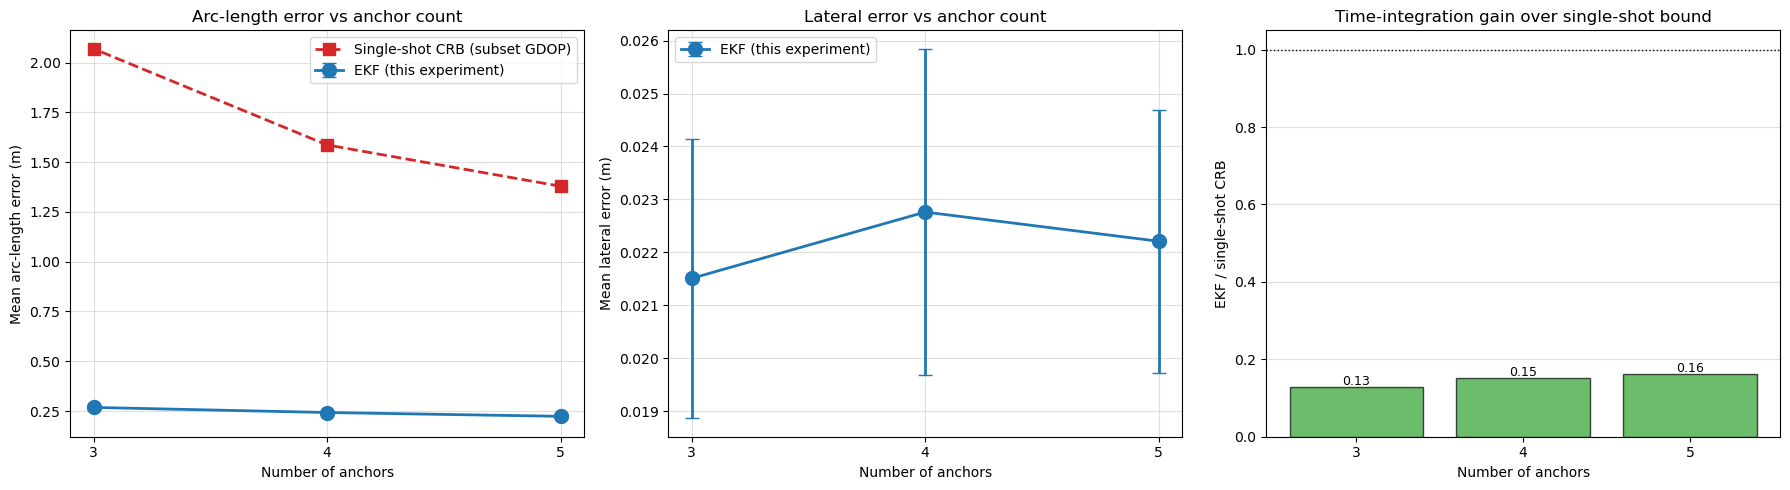


Saved: Figures_WeitingWu/B5_beacon_count_ablation.png


In [6]:
# ============================================================
# B5: Beacon-count ablation — 30 trials × 3 configurations.
# Each subset gets its own GDOP benchmark (CRB = sigma_y * mean GDOP)
# computed over the actual track (patch 4); the table and the EKF
# experiment refer to identical anchor subsets.
# ============================================================

# Configurations specified by *kept* indices (clearer than 'drop')
configs = [
    {'name': 'N=5 (baseline)',     'keep': [0, 1, 2, 3, 4]},
    {'name': 'N=4 (drop a3)',      'keep': [0, 1, 3, 4]},
    {'name': 'N=3 (drop a3,a5)',   'keep': [0, 1, 3]},
]

N_trials_abl = 30
N_steps_abl  = 4300
warmup = 500

# Sample the centreline track
s_samples_abl = np.linspace(0, L, 200, endpoint=False)
track_pts_abl = np.array([s_to_xy(s) for s in s_samples_abl])

# ── Per-subset GDOP benchmark (patch 4) ─────────────────────────────────
for cfg in configs:
    sub_anchors = anchors[cfg['keep']]
    gdops = np.array([compute_gdop(p, sub_anchors) for p in track_pts_abl])
    finite = gdops[np.isfinite(gdops)]
    cfg['mean_gdop']  = float(np.mean(finite))
    cfg['crb_meters'] = float(1.5 * cfg['mean_gdop'])
    cfg['n_beacons']  = len(cfg['keep'])

# ── Helper: build CasADi h for any anchor subset ─────────────────────────
def build_h_subset(active_anchors):
    n_active = len(active_anchors)
    z_l = cs.SX.sym('z_l', nx)
    v_l = cs.SX.sym('v_l', n_active)
    s_mod_  = cs.fmod(z_l[0], L)
    ell_l   = z_l[1]
    th2_ = (np.pi/2 - alpha) - (s_mod_ - s1) / R_B
    th4_ = (-np.pi/2 + alpha) - (s_mod_ - s3) / R_A
    xy1_ = cs.vertcat(A_top[0] + s_mod_*cos_a,            A_top[1] - s_mod_*sin_a)
    xy2_ = cs.vertcat(B_centre[0] + R_B*cs.cos(th2_),     R_B*cs.sin(th2_))
    xy3_ = cs.vertcat(B_bot[0] - (s_mod_-s2)*cos_a,       B_bot[1] - (s_mod_-s2)*sin_a)
    xy4_ = cs.vertcat(R_A*cs.cos(th4_),                    R_A*cs.sin(th4_))
    xy_c_l = cs.if_else(s_mod_ < s1, xy1_,
             cs.if_else(s_mod_ < s2, xy2_,
             cs.if_else(s_mod_ < s3, xy3_, xy4_)))
    n1_ = cs.vertcat(sin_a,  cos_a)
    n2_ = cs.vertcat(cs.cos(th2_), cs.sin(th2_))
    n3_ = cs.vertcat(sin_a, -cos_a)
    n4_ = cs.vertcat(cs.cos(th4_), cs.sin(th4_))
    n_c_l = cs.if_else(s_mod_ < s1, n1_,
            cs.if_else(s_mod_ < s2, n2_,
            cs.if_else(s_mod_ < s3, n3_, n4_)))
    r_l = xy_c_l + ell_l * n_c_l
    h_l_sym = cs.vertcat(*[cs.norm_2(r_l - active_anchors[i]) + v_l[i]
                           for i in range(n_active)])
    h_l   = cs.Function('h_l',   [z_l, v_l], [h_l_sym])
    jhx_l = cs.Function('jhx_l', [z_l, v_l], [cs.jacobian(h_l_sym, z_l)])
    jhv_l = cs.Function('jhv_l', [z_l, v_l], [cs.jacobian(h_l_sym, v_l)])
    return h_l, jhx_l, jhv_l

# ── Run each configuration ──────────────────────────────────────────────
results = {}
print(f"Running beacon-count ablation: {N_trials_abl} trials × {len(configs)} configs")

for cfg in configs:
    sub_anchors = anchors[cfg['keep']]
    n_active    = len(sub_anchors)
    R_active    = (1.5**2) * np.eye(n_active)

    h_l, jhx_l, jhv_l = build_h_subset(sub_anchors)
    print(f"\n  {cfg['name']}: kept anchors {cfg['keep']}"
          f"  | self-consistent mean GDOP = {cfg['mean_gdop']:.3f}"
          f"  | CRB = {cfg['crb_meters']:.3f} m")

    arc_errs = np.zeros(N_trials_abl)
    lat_errs = np.zeros(N_trials_abl)

    for trial in range(N_trials_abl):
        rng = np.random.default_rng(SEED_B5 + trial + 1000 * cfg['n_beacons'])
        x_t          = np.array([0.0, 0.0, 10.0, 0.0])
        x_t_pred     = np.array([0.0, 0.0, 10.0, 0.0])
        sigma_t_pred = np.diag([100.0, 1.0, 25.0, 0.5])

        x_cache_l      = np.zeros((N_steps_abl, nx))
        x_meas_cache_l = np.zeros((N_steps_abl-1, nx))
        x_cache_l[0]   = x_t

        for t in range(N_steps_abl-1):
            v_t = rng.multivariate_normal([0]*n_active, R_active)
            y_t = h_l(x_t, v_t)

            # measurement update with subset measurement
            C_l   = jhx_l(x_t_pred, 0)
            Rv_l  = jhv_l(x_t_pred, 0)
            Z_l   = C_l @ sigma_t_pred @ C_l.T + Rv_l @ R_active @ Rv_l.T
            x_t_meas = x_t_pred + sigma_t_pred @ C_l.T @ np.linalg.solve(
                Z_l, y_t - h_l(x_t_pred, [0]*n_active))
            sigma_t_meas = sigma_t_pred - sigma_t_pred @ C_l.T @ np.linalg.solve(
                Z_l, C_l @ sigma_t_pred)
            x_t_meas     = np.array(x_t_meas).flatten()
            sigma_t_meas = np.array(sigma_t_meas)
            x_meas_cache_l[t] = x_t_meas

            # time update — uses A_jacobian / L_jacobian via global time_update
            sigma_t_pred, x_t_pred = time_update(sigma_t_meas, x_t_meas)

            # truth dynamics
            w_t = rng.multivariate_normal([0, 0], Q)
            x_t = f_dynamics(x_t, w_t)
            x_cache_l[t+1] = x_t

        arc_errs[trial] = float(np.mean(arc_error(
            x_cache_l[warmup:-1, 0], x_meas_cache_l[warmup:, 0], L)))
        lat_errs[trial] = float(np.mean(np.abs(
            x_cache_l[warmup:-1, 1] - x_meas_cache_l[warmup:, 1])))

    results[cfg['name']] = {
        'n_beacons': cfg['n_beacons'],
        'keep_idx':  cfg['keep'],
        'mean_gdop': cfg['mean_gdop'],
        'crb_m':     cfg['crb_meters'],
        'arc_mean_m': float(np.mean(arc_errs)),
        'arc_std_m':  float(np.std(arc_errs)),
        'lat_mean_m': float(np.mean(lat_errs)),
        'lat_std_m':  float(np.std(lat_errs)),
    }
    print(f"    arc = {results[cfg['name']]['arc_mean_m']:.3f}"
          f" ± {results[cfg['name']]['arc_std_m']:.3f} m,"
          f"  lat = {results[cfg['name']]['lat_mean_m']:.3f}"
          f" ± {results[cfg['name']]['lat_std_m']:.3f} m")

B5_results = {
    'N_trials_per_config': int(N_trials_abl),
    'N_steps':             int(N_steps_abl),
    'configs':             results,
    'seed_base':           SEED_B5,
}

# ── Plot ─────────────────────────────────────────────────────────────────
fig_abl, (ax_arc, ax_lat, ax_eff) = plt.subplots(1, 3, figsize=(18, 5))
ns_plot   = [c['n_beacons'] for c in configs]
arc_means = [results[c['name']]['arc_mean_m'] for c in configs]
arc_stds  = [results[c['name']]['arc_std_m']  for c in configs]
lat_means = [results[c['name']]['lat_mean_m'] for c in configs]
lat_stds  = [results[c['name']]['lat_std_m']  for c in configs]
crb_plot  = [results[c['name']]['crb_m']      for c in configs]

ax_arc.errorbar(ns_plot, arc_means, yerr=arc_stds, fmt='o-', lw=2, ms=10,
                color='tab:blue', label='EKF (this experiment)', capsize=5)
ax_arc.plot(ns_plot, crb_plot, 's--', lw=2, ms=8, color='tab:red',
            label='Single-shot CRB (subset GDOP)')
ax_arc.set_xlabel('Number of anchors')
ax_arc.set_ylabel('Mean arc-length error (m)')
ax_arc.set_title('Arc-length error vs anchor count')
ax_arc.set_xticks(ns_plot)
ax_arc.legend(fontsize=10)
ax_arc.grid(True, alpha=0.4)

ax_lat.errorbar(ns_plot, lat_means, yerr=lat_stds, fmt='o-', lw=2, ms=10,
                color='tab:blue', label='EKF (this experiment)', capsize=5)
ax_lat.set_xlabel('Number of anchors')
ax_lat.set_ylabel('Mean lateral error (m)')
ax_lat.set_title('Lateral error vs anchor count')
ax_lat.set_xticks(ns_plot)
ax_lat.legend(fontsize=10)
ax_lat.grid(True, alpha=0.4)


# Panel 3 — EKF efficiency relative to single-shot CRB (patch #5)
ratio = [results[c['name']]['arc_mean_m'] / results[c['name']]['crb_m']
         for c in configs]
bars = ax_eff.bar(ns_plot, ratio, color='tab:green', alpha=0.7, edgecolor='k')
ax_eff.axhline(1.0, color='k', ls=':', lw=1)
ax_eff.set_xlabel('Number of anchors')
ax_eff.set_ylabel('EKF / single-shot CRB')
ax_eff.set_title('Time-integration gain over single-shot bound')
ax_eff.set_xticks(ns_plot)
for bar, val in zip(bars, ratio):
    ax_eff.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f'{val:.2f}', ha='center', fontsize=9)
ax_eff.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig('Figures_WeitingWu/B5_beacon_count_ablation.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\nSaved: Figures_WeitingWu/B5_beacon_count_ablation.png")

Running near-boundary stress test...



  A: nominal: lat_mean=0.0277 m,  lat_bias=-0.0029 m,  max|ell|=0.092 m


  B: near +bound: lat_mean=0.0281 m,  lat_bias=-0.0010 m,  max|ell|=1.803 m


  C: near -bound: lat_mean=0.0280 m,  lat_bias=-0.0043 m,  max|ell|=1.803 m


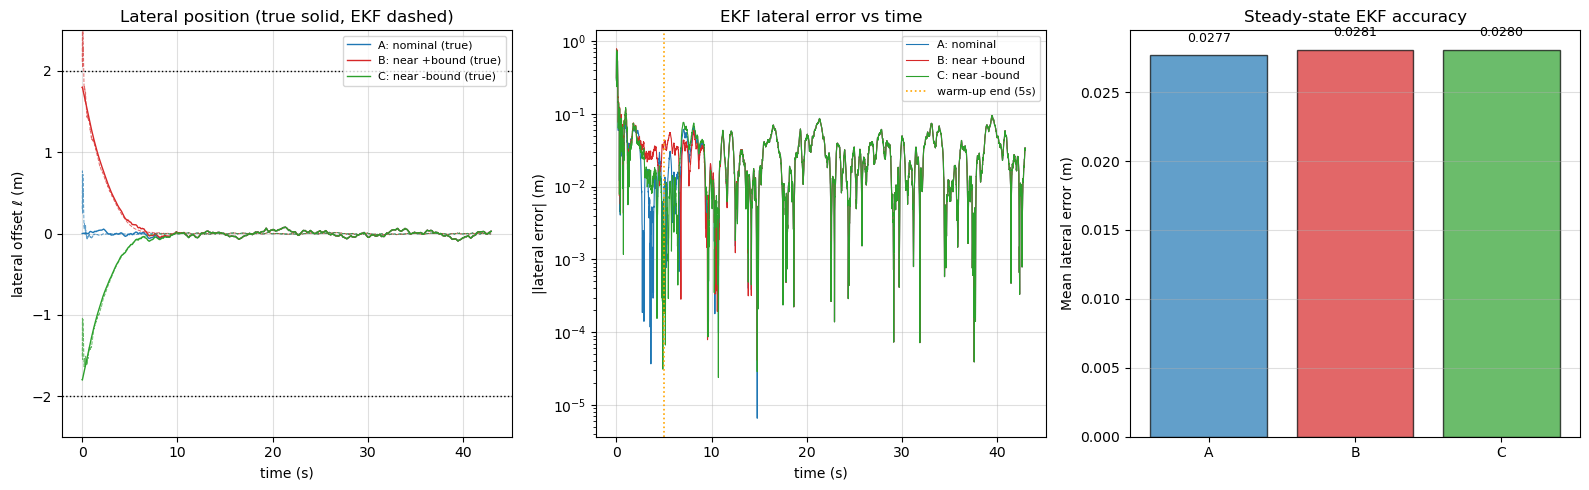


Saved: Figures_WeitingWu/B6_boundary_stress.png

Generating linear-vs-nonlinear truth comparison...


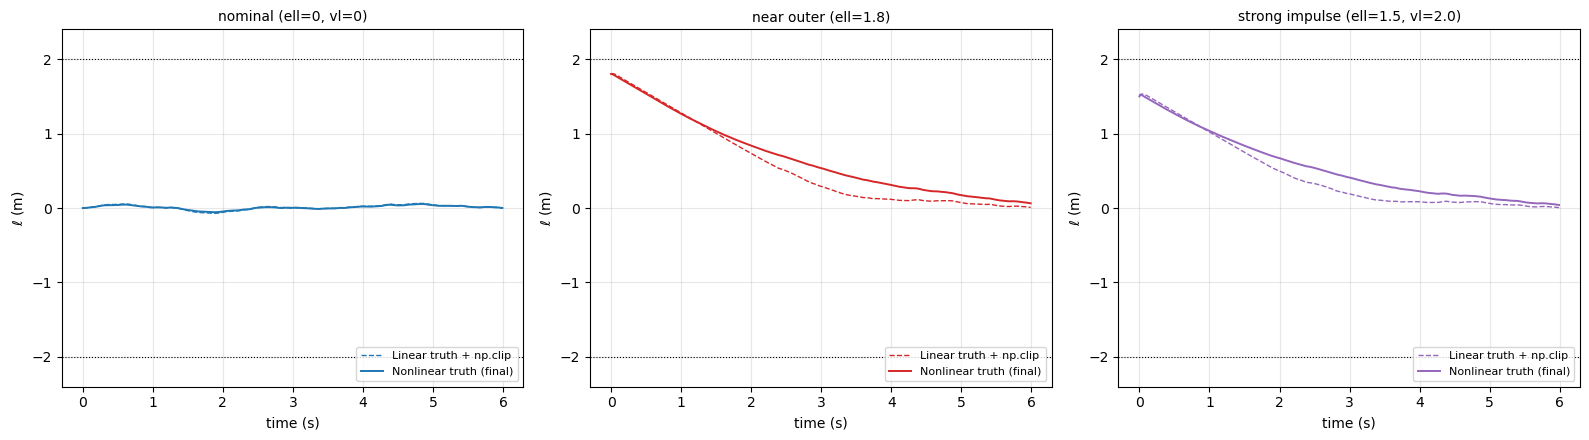

Saved: Figures_WeitingWu/B6_truth_comparison.png
  -> Centreline: linear and nonlinear models almost coincide.
  -> Near boundary: nonlinear stiffness pulls back smoothly; linear model only stays inside the lane because of np.clip.


In [7]:
# ============================================================
# B6: Near-boundary stress test (rubric C4 robustness).
# Three initial conditions:
#   A. nominal       (ell=0,    vl=0)
#   B. near +bound   (ell=+1.8, vl=+0.3)
#   C. near -bound   (ell=-1.8, vl=-0.3)
# Truth: f_dynamics (always); seeds fixed for fair comparison.
# ============================================================

scenarios = [
    {'name': 'A: nominal',     'ell0':  0.0, 'vl0':  0.0, 'color': 'tab:blue'},
    {'name': 'B: near +bound', 'ell0':  1.8, 'vl0':  0.3, 'color': 'tab:red'},
    {'name': 'C: near -bound', 'ell0': -1.8, 'vl0': -0.3, 'color': 'tab:green'},
]

N_steps_bd = 4300
warmup = 500
results_bd = {}

print("Running near-boundary stress test...\n")
for scn in scenarios:
    rng = np.random.default_rng(SEED_B6)        # same seed across scenarios
    x_t          = np.array([0.0, scn['ell0'], 10.0, scn['vl0']])
    x_t_pred     = np.array([0.0, scn['ell0'], 10.0, scn['vl0']])
    sigma_t_pred = np.diag([100.0, 1.0, 25.0, 0.5])

    x_cache_bd      = np.zeros((N_steps_bd,   nx))
    x_meas_cache_bd = np.zeros((N_steps_bd-1, nx))
    x_cache_bd[0]   = x_t

    for t in range(N_steps_bd-1):
        v_t = rng.multivariate_normal([0]*ny, R)
        y_t = h(x_t, v_t)

        sigma_t_meas, x_t_meas = measurement_update(sigma_t_pred, x_t_pred, y_t)
        x_meas_cache_bd[t] = x_t_meas

        sigma_t_pred, x_t_pred = time_update(sigma_t_meas, x_t_meas)

        w_t = rng.multivariate_normal([0, 0], Q)
        x_t = f_dynamics(x_t, w_t)
        x_cache_bd[t+1] = x_t

    lat_err  = np.abs(x_cache_bd[warmup:-1, 1] - x_meas_cache_bd[warmup:, 1])
    lat_bias = float(np.mean(x_cache_bd[warmup:-1, 1] - x_meas_cache_bd[warmup:, 1]))
    max_ell  = float(np.max(np.abs(x_cache_bd[:, 1])))

    results_bd[scn['name']] = {
        'x_true':   x_cache_bd,
        'x_meas':   x_meas_cache_bd,
        'lat_mean': float(np.mean(lat_err)),
        'lat_max':  float(np.max(lat_err)),
        'lat_bias': lat_bias,
        'max_ell':  max_ell,
        'color':    scn['color'],
    }
    print(f"  {scn['name']}: lat_mean={results_bd[scn['name']]['lat_mean']:.4f} m,  "
          f"lat_bias={lat_bias:+.4f} m,  max|ell|={max_ell:.3f} m")

B6_results = {
    'scenarios': {
        name: {
            'lat_mean_m': r['lat_mean'],
            'lat_max_m':  r['lat_max'],
            'lat_bias_m': r['lat_bias'],
            'max_abs_ell_m': r['max_ell'],
        }
        for name, r in results_bd.items()
    },
    'seed': SEED_B6,
}

# ── Plot ─────────────────────────────────────────────────────────────────
fig_bd, axes_bd = plt.subplots(1, 3, figsize=(16, 5))
t_ax_bd = np.arange(N_steps_bd) * dt

ax1 = axes_bd[0]
for name, r in results_bd.items():
    ax1.plot(t_ax_bd, r['x_true'][:, 1], color=r['color'], lw=1,
             label=f'{name} (true)')
    ax1.plot(t_ax_bd[:-1], r['x_meas'][:, 1], color=r['color'], lw=0.7,
             ls='--', alpha=0.7)
ax1.axhline( 2.0, color='k', ls=':', lw=1)
ax1.axhline(-2.0, color='k', ls=':', lw=1)
ax1.set_xlabel('time (s)');  ax1.set_ylabel(r'lateral offset $\ell$ (m)')
ax1.set_title('Lateral position (true solid, EKF dashed)')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.4)
ax1.set_ylim([-2.5, 2.5])

ax2 = axes_bd[1]
for name, r in results_bd.items():
    err = np.abs(r['x_true'][:-1, 1] - r['x_meas'][:, 1])
    ax2.plot(t_ax_bd[:-1], err, color=r['color'], lw=0.8, label=name)
ax2.axvline(warmup*dt, color='orange', ls=':', lw=1.2,
            label=f'warm-up end ({warmup*dt:.0f}s)')
ax2.set_xlabel('time (s)');  ax2.set_ylabel('|lateral error| (m)')
ax2.set_title('EKF lateral error vs time')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.4);  ax2.set_yscale('log')

ax3 = axes_bd[2]
names_bd  = list(results_bd.keys())
means_bd  = [results_bd[n]['lat_mean'] for n in names_bd]
colors_bd = [results_bd[n]['color']    for n in names_bd]
bars = ax3.bar(range(len(names_bd)), means_bd, color=colors_bd, alpha=0.7,
               edgecolor='k')
ax3.set_xticks(range(len(names_bd)))
ax3.set_xticklabels([n.split(':')[0] for n in names_bd])
ax3.set_ylabel('Mean lateral error (m)')
ax3.set_title('Steady-state EKF accuracy')
for bar, val in zip(bars, means_bd):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.001,
             f'{val:.4f}', ha='center', fontsize=9)
ax3.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig('Figures_WeitingWu/B6_boundary_stress.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\nSaved: Figures_WeitingWu/B6_boundary_stress.png")

# ── Patch #6: linear-vs-nonlinear truth model comparison ────────────────
print("\nGenerating linear-vs-nonlinear truth comparison...")
def f_linear_truth(z, w_vec):
    """Linear surrogate truth model with post-hoc np.clip — used here ONLY
    to visualise the gap that the unified nonlinear model closes."""
    s, ell, vs, vl = z
    s_n   = s + dt * vs
    ell_n = ell + dt * vl
    vs_n  = phi_vs * vs + (1-phi_vs)*VS_TGT_NL + w_vec[0]
    vl_n  = phi_1  * vl - dt*k2*ell + w_vec[1]
    vs_n  = float(np.clip(vs_n,  VS_MIN_NL, VS_MAX_NL))
    vl_n  = float(np.clip(vl_n, -VL_MAX_NL, VL_MAX_NL))
    ell_n = float(np.clip(ell_n, -ELL_MAX_NL, ELL_MAX_NL))
    return np.array([s_n, ell_n, vs_n, vl_n])

cmp_scenarios = [
    ('nominal (ell=0, vl=0)',  0.0,  0.0, 'tab:blue'),
    ('near outer (ell=1.8)',   1.8,  0.3, 'tab:red'),
    ('strong impulse (ell=1.5, vl=2.0)', 1.5, 2.0, 'tab:purple'),
]

fig_cmp, axes_cmp = plt.subplots(1, 3, figsize=(16, 4.5))
N_cmp = 600
for ax, (name, ell0, vl0, col) in zip(axes_cmp, cmp_scenarios):
    rng_cmp = np.random.default_rng(SEED_B6)
    x_lin = np.array([0.0, ell0, 10.0, vl0])
    x_nl  = np.array([0.0, ell0, 10.0, vl0])
    traj_lin = np.zeros(N_cmp); traj_nl = np.zeros(N_cmp)
    traj_lin[0] = ell0;          traj_nl[0] = ell0
    for tt in range(1, N_cmp):
        wt = rng_cmp.multivariate_normal([0,0], Q)
        x_lin = f_linear_truth(x_lin, wt)
        x_nl  = f_dynamics(x_nl, wt)
        traj_lin[tt] = x_lin[1]
        traj_nl[tt]  = x_nl[1]
    t_cmp = np.arange(N_cmp) * dt
    ax.plot(t_cmp, traj_lin, color=col, lw=1.0, ls='--',
            label='Linear truth + np.clip')
    ax.plot(t_cmp, traj_nl,  color=col, lw=1.4, ls='-',
            label='Nonlinear truth (final)')
    ax.axhline( 2.0, color='k', ls=':', lw=0.8)
    ax.axhline(-2.0, color='k', ls=':', lw=0.8)
    ax.set_ylim([-2.4, 2.4])
    ax.set_xlabel('time (s)')
    ax.set_ylabel(r'$\ell$ (m)')
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Figures_WeitingWu/B6_truth_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: Figures_WeitingWu/B6_truth_comparison.png")
print("  -> Centreline: linear and nonlinear models almost coincide.")
print("  -> Near boundary: nonlinear stiffness pulls back smoothly; "
      "linear model only stays inside the lane because of np.clip.")

In [8]:
# ============================================================
# Patch 6: dump every numerical result this notebook produced into
# results_summary.json. The report cites these numbers verbatim, so
# any drift is detected the next time the notebook is executed.
# ============================================================
try:
    import casadi as _casadi_pkg
    _casadi_version = _casadi_pkg.__version__
except Exception:
    _casadi_version = 'unknown'

def _to_jsonable(o):
    import numpy as _np
    if isinstance(o, _np.integer):  return int(o)
    if isinstance(o, _np.floating): return float(o)
    if isinstance(o, _np.bool_):    return bool(o)
    if isinstance(o, _np.ndarray):  return o.tolist()
    return o

results_summary = {
    'meta': {
        'master_seed':    MASTER_SEED,
        'numpy_version':  np.__version__,
        'casadi_version': _casadi_version,
    },
    'parameters': {
        'L_track_m':  float(L),
        'dt_s':       float(dt),
        'n_anchors':  int(ny),
        'Q_diag':     [float(Q[0,0]), float(Q[1,1])],
        'sigma_y_m':  float(np.sqrt(R[0,0])),
        'phi_vs':     float(phi_vs),
        'phi_1':      float(phi_1),
        'k2':         float(k2),
    },
    'EKF_timing':           EKF_TIMING,
    'B1_single_run':        B1_results,
    'B2_monte_carlo':       B2_results,
    'B3_mhe':               B3_results,
    'B4_bias_augmented':    B4_results,
    'B5_beacon_ablation':   B5_results,
    'B6_boundary_stress':   B6_results,
}

with open('results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2, default=_to_jsonable)

print("results_summary.json written.")
print(f"  B1 mean arc error  : {B1_results['mean_arc_err_m']:.3f} m")
print(f"  B2 mean arc error  : {B2_results['arc_mean_m']:.3f} m   "
      f"(NIS empirical mean = {B2_results['nis_mean']:.3f})")
print(f"  B3 MHE solve time  : {B3_results['mean_solve_ms']:.1f} ms"
      f"  ({B3_results['slowdown_factor']:.0f}x over budget)")
print(f"  B4 max bias error  : {B4_results['max_abs_bias_err_m']:.4f} m")
print(f"  B5 N=5 EKF arc err : "
      f"{B5_results['configs']['N=5 (baseline)']['arc_mean_m']:.3f} m")
print(f"  B6 max |ell|       : "
      f"{max(B6_results['scenarios'][s]['max_abs_ell_m'] for s in B6_results['scenarios']):.3f} m")
print(f"  EKF per-step time  : {EKF_TIMING['per_step_ms']:.3f} ms"
      f"  (budget {EKF_TIMING['budget_ms']:.0f} ms,"
      f"  using {EKF_TIMING['budget_fraction']*100:.1f}%)")

results_summary.json written.
  B1 mean arc error  : 0.239 m
  B2 mean arc error  : 0.226 m   (NIS empirical mean = 4.994)
  B3 MHE solve time  : 1275.2 ms  (128x over budget)
  B4 max bias error  : 0.0354 m
  B5 N=5 EKF arc err : 0.223 m
  B6 max |ell|       : 1.803 m
  EKF per-step time  : 0.429 ms  (budget 10 ms,  using 4.3%)
